In [ ]:
# ============================================================
# Instalaciones
# ============================================================

#Esta celda instala las librerías que necesito para ejecutar el notebook. Aquí preparo el entorno para poder cargar BETO, calcular embeddings y hacer las visualizaciones del análisis.
!pip install transformers torch umap-learn scikit-learn matplotlib seaborn -q


In [ ]:
# ============================================================
# Imports y carga
# ============================================================

#En esta celda importo las librerías que voy a usar en todo el análisis y cargo el archivo CSV con el corpus final. Después imprimo el tamaño del dataset, las columnas y la distribución por partido y por período para comprobar que los datos se han cargado bien y que la estructura del corpus es la esperada.
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

df = pd.read_csv("/content/INTERVENCIONES_COVID_TFG.csv")
print(df.shape)
print(df.columns.tolist())
print(df["partido"].value_counts().to_string())
print(df["period"].value_counts().to_string())

(1471, 11)
['intervention', 'fecha', 'legislatura', 'namey', 'oradorx', 'role', 'oradorx_id', 'period', 'text', 'n_words', 'partido']
partido
PSOE              449
PP                187
VOX               122
Unidas Podemos    120
ERC                70
Cs                 68
PNV                62
EH Bildu           59
JxCat              44
CUP                40
BNG                37
Más País           35
Compromís          31
Foro Asturias      30
PRC                24
CC                 22
UPN                21
PDeCAT             19
Teruel Existe      18
NC/CC              12
Mixto               1
period
pre     758
post    713


1. DISCURSOS POR PERÍODO
period
pre     758
post    713
Total: 1471

2. SPEAKERS ÚNICOS
Total:       210
Pre alarma:  178
Post alarma: 123

3. DISTRIBUCIÓN POR PARTIDO Y PERÍODO
period          post  pre  total   pct
partido                               
PSOE             220  229    449  30.5
PP               101   86    187  12.7
VOX               57   65    122   8.3
Unidas Podemos    72   48    120   8.2
ERC               32   38     70   4.8
Cs                21   47     68   4.6
PNV               27   35     62   4.2
EH Bildu          25   34     59   4.0
JxCat             18   26     44   3.0
CUP               16   24     40   2.7
BNG               20   17     37   2.5
Más País          20   15     35   2.4
Compromís         15   16     31   2.1
Foro Asturias     14   16     30   2.0
PRC               10   14     24   1.6
CC                11   11     22   1.5
UPN               13    8     21   1.4
PDeCAT             6   13     19   1.3
Teruel Existe     10    8     18   1.2
NC/

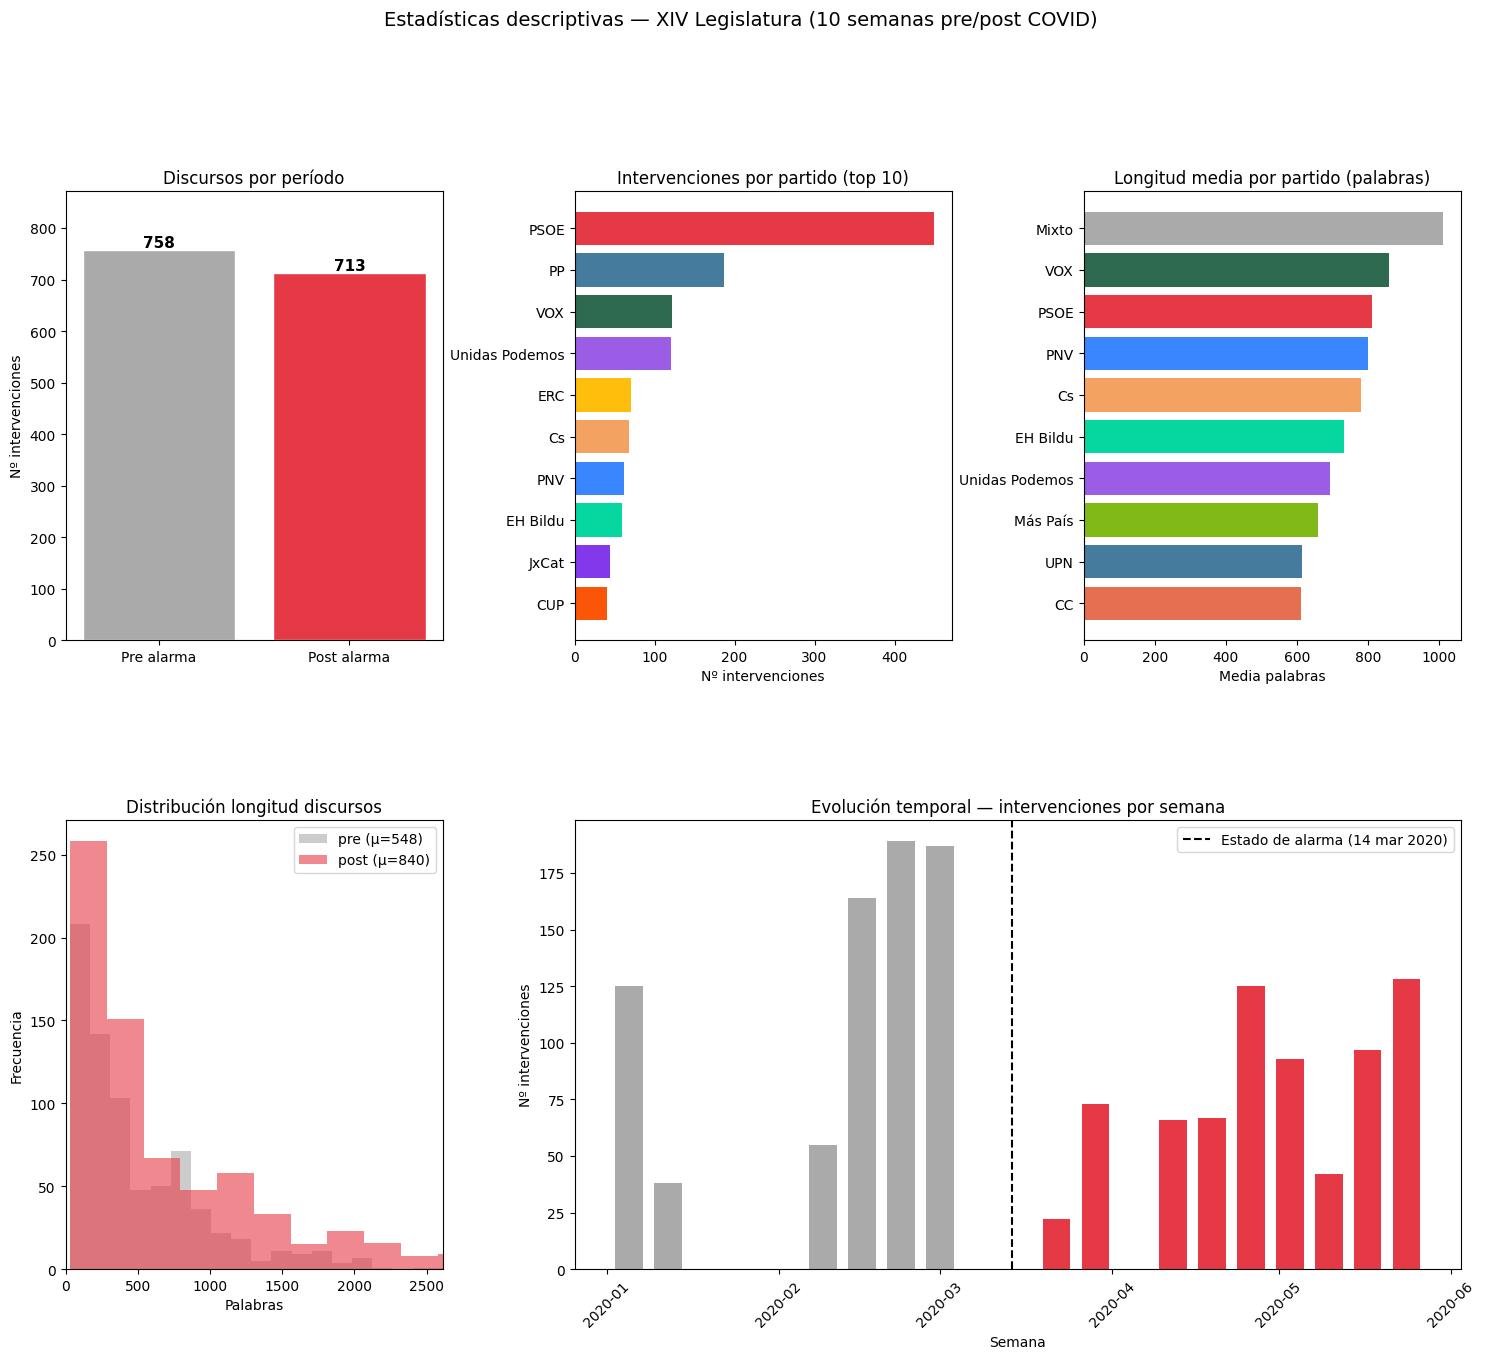

In [ ]:
# ============================================================
# Estadísticas descriptivas
# ============================================================

# En esta celda calculo los descriptivos básicos del corpus y genero las primeras figuras de contexto. Primero saco el número de intervenciones por período, el número de oradores únicos, la distribución por partido y la longitud de los discursos. Después lo complemento con gráficos para visualizar mejor el reparto del corpus y comprobar si hay diferencias claras entre el período pre y el post
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


df["fecha_dt"] = pd.to_datetime(df["fecha"], errors="coerce")

print("=" * 50)
print("1. DISCURSOS POR PERÍODO")
print("=" * 50)
print(df["period"].value_counts().to_string())
print(f"Total: {len(df)}")

print("\n" + "=" * 50)
print("2. SPEAKERS ÚNICOS")
print("=" * 50)
print(f"Total:       {df['oradorx'].nunique()}")
print(f"Pre alarma:  {df[df['period']=='pre']['oradorx'].nunique()}")
print(f"Post alarma: {df[df['period']=='post']['oradorx'].nunique()}")

print("\n" + "=" * 50)
print("3. DISTRIBUCIÓN POR PARTIDO Y PERÍODO")
print("=" * 50)
tabla = df.groupby(["partido","period"]).size().unstack(fill_value=0)
tabla["total"] = tabla.sum(axis=1)
tabla["pct"]   = (tabla["total"] / len(df) * 100).round(1)
print(tabla.sort_values("total", ascending=False).to_string())

print("\n" + "=" * 50)
print("4. LONGITUD MEDIA DE DISCURSOS (palabras)")
print("=" * 50)
print(df.groupby("period")["n_words"].agg(["mean","median","std","min","max"]).round(1).to_string())
print(f"\nGlobal — media: {df['n_words'].mean():.1f} | mediana: {df['n_words'].median():.1f}")
print("\nPor partido:")
print(df.groupby("partido")["n_words"].mean().sort_values(ascending=False).round(1).to_string())

# Gráficos
COLORES_PARTIDO = {
    "PSOE":"#E63946","PP":"#457B9D","VOX":"#2D6A4F",
    "Unidas Podemos":"#9B5DE5","Cs":"#F4A261","ERC":"#FFBE0B",
    "PNV":"#3A86FF","EH Bildu":"#06D6A0","JxCat":"#8338EC",
    "CUP":"#FB5607","Más País":"#80B918","BNG":"#023E8A",
    "Compromís":"#E9C46A","Foro Asturias":"#264653","PRC":"#2A9D8F",
    "CC":"#E76F51","Teruel Existe":"#6D6875","NC/CC":"#B5838D",
    "UPN":"#457B9D","Mixto":"#aaaaaa"
}

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Gráfico 1: discursos por período
ax1 = fig.add_subplot(gs[0, 0])
counts = df["period"].value_counts()[["pre","post"]]
ax1.bar(["Pre alarma","Post alarma"], counts.values,
        color=["#aaaaaa","#E63946"], edgecolor="white")
for i, v in enumerate(counts.values):
    ax1.text(i, v+5, str(v), ha="center", fontsize=11, fontweight="bold")
ax1.set_title("Discursos por período", fontsize=12)
ax1.set_ylabel("Nº intervenciones")
ax1.set_ylim(0, max(counts.values)*1.15)

# Gráfico 2: intervenciones por partido top 10
ax2 = fig.add_subplot(gs[0, 1])
top10 = df["partido"].value_counts().head(10)
ax2.barh(top10.index[::-1], top10.values[::-1],
         color=[COLORES_PARTIDO.get(p,"#aaaaaa") for p in top10.index[::-1]])
ax2.set_title("Intervenciones por partido (top 10)", fontsize=12)
ax2.set_xlabel("Nº intervenciones")

# Gráfico 3: longitud media por partido top 10
ax3 = fig.add_subplot(gs[0, 2])
long_p = df.groupby("partido")["n_words"].mean().sort_values(ascending=False).head(10)
ax3.barh(long_p.index[::-1], long_p.values[::-1],
         color=[COLORES_PARTIDO.get(p,"#aaaaaa") for p in long_p.index[::-1]])
ax3.set_title("Longitud media por partido (palabras)", fontsize=12)
ax3.set_xlabel("Media palabras")

# Gráfico 4: distribución longitud pre vs post
ax4 = fig.add_subplot(gs[1, 0])
for periodo, color in [("pre","#aaaaaa"),("post","#E63946")]:
    sub = df[df["period"]==periodo]["n_words"]
    ax4.hist(sub, bins=40, alpha=0.6, color=color,
             label=f"{periodo} (μ={sub.mean():.0f})", edgecolor="none")
ax4.set_title("Distribución longitud discursos", fontsize=12)
ax4.set_xlabel("Palabras")
ax4.set_ylabel("Frecuencia")
ax4.legend()
ax4.set_xlim(0, df["n_words"].quantile(0.97))

# Gráfico 5: evolución temporal semanal
ax5 = fig.add_subplot(gs[1, 1:])
evol = (df.set_index("fecha_dt").resample("W")["period"]
        .count().reset_index())
evol.columns = ["fecha","n"]
ax5.bar(evol["fecha"], evol["n"],
        color=["#aaaaaa" if f < pd.Timestamp("2020-03-14") else "#E63946"
               for f in evol["fecha"]], width=5)
ax5.axvline(pd.Timestamp("2020-03-14"), color="black",
            linestyle="--", linewidth=1.5, label="Estado de alarma (14 mar 2020)")
ax5.set_title("Evolución temporal — intervenciones por semana", fontsize=12)
ax5.set_xlabel("Semana")
ax5.set_ylabel("Nº intervenciones")
ax5.legend()
plt.xticks(rotation=45)

plt.suptitle("Estadísticas descriptivas — XIV Legislatura (10 semanas pre/post COVID)",
             fontsize=14, y=1.01)
plt.savefig("descriptivos.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#Esta línea muestra cuántas intervenciones hay en cada fecha dentro de cada período. Me sirve como comprobación rápida para ver cómo se distribuye el corpus en el tiempo y detectar si hay días con mucha concentración de discursos.
print(df.groupby(["period","fecha_dt"]).size().reset_index().to_string())

   period   fecha_dt    0
0    post 2020-03-18   22
1    post 2020-03-25   73
2    post 2020-04-09   66
3    post 2020-04-15   67
4    post 2020-04-22  125
5    post 2020-04-29   93
6    post 2020-05-06   42
7    post 2020-05-13   97
8    post 2020-05-20  128
9     pre 2020-01-04   77
10    pre 2020-01-05   48
11    pre 2020-01-07   38
12    pre 2020-02-04   55
13    pre 2020-02-11   91
14    pre 2020-02-12   73
15    pre 2020-02-18   95
16    pre 2020-02-19   77
17    pre 2020-02-20   17
18    pre 2020-02-25   70
19    pre 2020-02-26   92
20    pre 2020-02-27   25


In [ ]:
# ============================================================
# Carga del modelo BETO
# ============================================================

#En esta celda cargo BETO, que es el modelo que voy a usar para generar los embeddings de las intervenciones. También lo paso al dispositivo disponible, usando GPU si está activada, para acelerar el cálculo.

#Cargo el modelo BETO en español que voy a usar para generar los embeddings
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

#Cargo el tokenizador y el modelo preentrenado
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
print(f"Usando: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Usando: cuda


In [ ]:
# ============================================================
# Función de embedding (con chunking para textos largos)
# ============================================================
# esta función genera un embedding para cada intervención del corpus
# si el texto supera el límite de BERT, lo divido en varios fragmentos y luego promedío sus embeddings
def get_embeddings(texts: list, batch_size: int = 16) -> np.ndarray:
    all_embeddings = []

    # Recorro todos los textos del corpus
    for i, text in enumerate(tqdm(texts, desc="Embeddings")):
        tokens = tokenizer.encode(str(text), add_special_tokens=False)

        # Si el texto cabe en una sola pasada del modelo, lo proceso directamente
        if len(tokens) <= 510:
            encoded = tokenizer(
                str(text),
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)
            with torch.no_grad():
                output = model(**encoded)

            # Hago mean pooling sobre los tokens válidos usando la attention mask
            mask = encoded["attention_mask"].unsqueeze(-1).expand(
                output.last_hidden_state.size()).float()
            emb = torch.sum(output.last_hidden_state * mask, 1) / \
                  torch.clamp(mask.sum(1), min=1e-9)
            all_embeddings.append(emb.cpu().numpy())

        # Si el texto es demasiado largo, lo divido en chunks de 510 tokens
        else:
            chunks = [tokens[j:j+510] for j in range(0, len(tokens), 510)]
            chunk_embeddings = []

            # Calculo un embedding para cada chunk
            for chunk in chunks:
                input_ids = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
                input_ids = torch.tensor([input_ids]).to(device)
                attention_mask = torch.ones_like(input_ids)
                with torch.no_grad():
                    output = model(input_ids=input_ids, attention_mask=attention_mask)

                # Vuelvo a aplicar mean pooling en cada fragmento
                mask = attention_mask.unsqueeze(-1).expand(
                    output.last_hidden_state.size()).float()
                emb = torch.sum(output.last_hidden_state * mask, 1) / \
                      torch.clamp(mask.sum(1), min=1e-9)
                chunk_embeddings.append(emb.cpu().numpy())

            # El embedding final del texto largo es la media de los embeddings de sus chunks
            all_embeddings.append(np.mean(chunk_embeddings, axis=0))

    # Junto todos los embeddings en una sola matriz final
    return np.vstack(all_embeddings)

In [ ]:
# ============================================================
# Calcular embeddings
# ============================================================

# Extraigo todas las intervenciones del dataframe como lista de textos
texts      = df["intervention"].astype(str).tolist()

# Genero un embedding para cada intervención del corpus
embeddings = get_embeddings(texts)

#Guardo la matriz de embeddings para poder reutilizarla sin recalcular todo
np.save("embeddings_beto.npy", embeddings)
print(f"Shape: {embeddings.shape}")


Embeddings:   0%|          | 2/1471 [00:01<11:57,  2.05it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (4505 > 512). Running this sequence through the model will result in indexing errors

Embeddings: 100%|██████████| 1471/1471 [01:37<00:00, 15.11it/s]

Shape: (1471, 768)


In [ ]:
# ============================================================
# ANÁLISIS: Distancia coseno entre centroides
# ============================================================

# Nos centramos en los cuatro partidos principales del análisis sustantivo
PARTIDOS_PRINCIPALES = ["PSOE", "PP", "VOX", "Unidas Podemos"]

# Esta función calcula el centroide de un partido en un período concreto
def centroide(partido, periodo):
    idx = df[(df["partido"] == partido) & (df["period"] == periodo)].index
    return embeddings[idx].mean(axis=0)

# Cambio interno de cada partido pre --> post
print("=== Cambio discursivo interno pre→post ===")
resultados = []
for partido in PARTIDOS_PRINCIPALES:
    c_pre  = centroide(partido, "pre")
    c_post = centroide(partido, "post")
    dist   = 1 - cosine_similarity([c_pre], [c_post])[0][0]
    resultados.append({"partido": partido, "distancia_pre_post": round(dist, 4)})
    print(f"  {partido}: {dist:.4f}")

# Distancia PP vs PSOE por periodo
print("\n=== Distancia PP vs PSOE ===")
for periodo in ["pre", "post"]:
    c_pp   = centroide("PP",   periodo)
    c_psoe = centroide("PSOE", periodo)
    dist   = 1 - cosine_similarity([c_pp], [c_psoe])[0][0]
    print(f"  {periodo}: {dist:.4f}")

# Matriz completa de distancias entre los cuatro partidos en el período post
print("\n=== Matriz de distancias post ===")
centroides_post = {p: centroide(p, "post") for p in PARTIDOS_PRINCIPALES}
mat = pd.DataFrame(index=PARTIDOS_PRINCIPALES, columns=PARTIDOS_PRINCIPALES, dtype=float)
for p1 in PARTIDOS_PRINCIPALES:
    for p2 in PARTIDOS_PRINCIPALES:
        mat.loc[p1, p2] = round(
            1 - cosine_similarity([centroides_post[p1]], [centroides_post[p2]])[0][0], 4)
print(mat.to_string())

=== Cambio discursivo interno pre→post ===
  PSOE: 0.0024
  PP: 0.0012
  VOX: 0.0019
  Unidas Podemos: 0.0016

=== Distancia PP vs PSOE ===
  pre: 0.0017
  post: 0.0041

=== Matriz de distancias post ===
                  PSOE      PP     VOX  Unidas Podemos
PSOE            0.0000  0.0041  0.0037          0.0010
PP              0.0041 -0.0000  0.0013          0.0030
VOX             0.0037  0.0013  0.0000          0.0027
Unidas Podemos  0.0010  0.0030  0.0027          0.0000


In [ ]:
# ============================================================
# Matriz de distancias PRE + cambio bilateral pre→post
# ============================================================

# Matriz completa de distancias entre los cuatro partidos en el período pre
print("=== Matriz de distancias pre ===")
centroides_pre = {p: centroide(p, "pre") for p in PARTIDOS_PRINCIPALES}
mat_pre = pd.DataFrame(index=PARTIDOS_PRINCIPALES, columns=PARTIDOS_PRINCIPALES, dtype=float)
for p1 in PARTIDOS_PRINCIPALES:
    for p2 in PARTIDOS_PRINCIPALES:
        mat_pre.loc[p1, p2] = round(
            1 - cosine_similarity([centroides_pre[p1]], [centroides_pre[p2]])[0][0], 4)
print(mat_pre.to_string())

# Comparo cada par de partidos entre pre y post para ver cuánto aumenta o disminuye su distancia
print("\n=== Cambio bilateral pre→post (todos los pares) ===")
pares = [(p1, p2) for i, p1 in enumerate(PARTIDOS_PRINCIPALES)
         for p2 in PARTIDOS_PRINCIPALES[i+1:]]
for p1, p2 in pares:
    d_pre  = mat_pre.loc[p1, p2]
    d_post = mat.loc[p1, p2]
    ratio  = round(d_post / d_pre, 2) if d_pre > 0 else float('inf')
    print(f"  {p1:20s} vs {p2:20s}  pre={d_pre:.4f}  post={d_post:.4f}  x{ratio}")

=== Matriz de distancias pre ===
                  PSOE      PP     VOX  Unidas Podemos
PSOE           -0.0000  0.0017  0.0012          0.0011
PP              0.0017 -0.0000  0.0009          0.0017
VOX             0.0012  0.0009 -0.0000          0.0013
Unidas Podemos  0.0011  0.0017  0.0013          0.0000

=== Cambio bilateral pre→post (todos los pares) ===
  PSOE                 vs PP                    pre=0.0017  post=0.0041  x2.41
  PSOE                 vs VOX                   pre=0.0012  post=0.0037  x3.08
  PSOE                 vs Unidas Podemos        pre=0.0011  post=0.0010  x0.91
  PP                   vs VOX                   pre=0.0009  post=0.0013  x1.44
  PP                   vs Unidas Podemos        pre=0.0017  post=0.0030  x1.76
  VOX                  vs Unidas Podemos        pre=0.0013  post=0.0027  x2.08


In [ ]:
# ============================================================
# Tests de permutación: todos los pares post + cambios internos
# ============================================================

# Defino los pares que voy a comparar, incluyendo tanto cambios internos pre-->post como distancias entre partidos en post
pares_completos = [
    ("PSOE", "pre",  "PSOE", "post",           "Cambio interno PSOE"),
    ("PP",   "pre",  "PP",   "post",            "Cambio interno PP"),
    ("VOX",  "pre",  "VOX",  "post",            "Cambio interno VOX"),
    ("Unidas Podemos","pre","Unidas Podemos","post","Cambio interno UP"),
    ("PP",   "post", "PSOE", "post",            "PP vs PSOE post"),
    ("VOX",  "post", "PSOE", "post",            "VOX vs PSOE post"),
    ("Unidas Podemos","post","PSOE","post",      "UP vs PSOE post"),
    ("PP",   "post", "VOX",  "post",            "PP vs VOX post"),
    ("PP",   "post", "Unidas Podemos","post",   "PP vs UP post"),
    ("VOX",  "post", "Unidas Podemos","post",   "VOX vs UP post"),
]

print("=== Tests de permutaciones — todos los pares ===\n")

# Fijo la semilla para que los resultados sean reproducibles
np.random.seed(42)
for p1, per1, p2, per2, etiqueta in pares_completos:
    idx1 = df[(df["partido"]==p1) & (df["period"]==per1)].index
    idx2 = df[(df["partido"]==p2) & (df["period"]==per2)].index
    emb1, emb2 = embeddings[idx1], embeddings[idx2]
    todos = np.vstack([emb1, emb2])
    n1 = len(emb1)

    # Calculo la distancia observada entre los dos grupos que comparo
    dist_obs = 1 - cosine_similarity([emb1.mean(axis=0)],[emb2.mean(axis=0)])[0][0]
    dist_perm = []
    # Genero la distribución nula mediante 1000 permutaciones aleatorias
    for _ in range(1000):
        perm = np.random.permutation(len(todos))
        c1 = todos[perm[:n1]].mean(axis=0)
        c2 = todos[perm[n1:]].mean(axis=0)
        dist_perm.append(1 - cosine_similarity([c1],[c2])[0][0])

    # Calculo el p-valor y el ratio frente a la distancia media de las permutaciones
    p_val = np.mean(np.array(dist_perm) >= dist_obs)
    ratio = dist_obs / np.mean(dist_perm)
    sig   = "✅ p<0.05" if p_val < 0.05 else "❌ no sig."
    print(f"  {etiqueta:35s}  dist={dist_obs:.4f}  p={p_val:.4f}  ratio={ratio:.1f}x  {sig}")

=== Tests de permutaciones — todos los pares ===

  Cambio interno PSOE                  dist=0.0024  p=0.0000  ratio=12.6x  ✅ p<0.05
  Cambio interno PP                    dist=0.0012  p=0.0000  ratio=2.9x  ✅ p<0.05
  Cambio interno VOX                   dist=0.0019  p=0.0000  ratio=3.1x  ✅ p<0.05
  Cambio interno UP                    dist=0.0016  p=0.0000  ratio=2.4x  ✅ p<0.05
  PP vs PSOE post                      dist=0.0041  p=0.0000  ratio=15.1x  ✅ p<0.05
  VOX vs PSOE post                     dist=0.0037  p=0.0000  ratio=9.8x  ✅ p<0.05
  UP vs PSOE post                      dist=0.0010  p=0.0000  ratio=3.0x  ✅ p<0.05
  PP vs VOX post                       dist=0.0013  p=0.0010  ratio=2.6x  ✅ p<0.05
  PP vs UP post                        dist=0.0030  p=0.0000  ratio=6.5x  ✅ p<0.05
  VOX vs UP post                       dist=0.0027  p=0.0000  ratio=5.1x  ✅ p<0.05


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


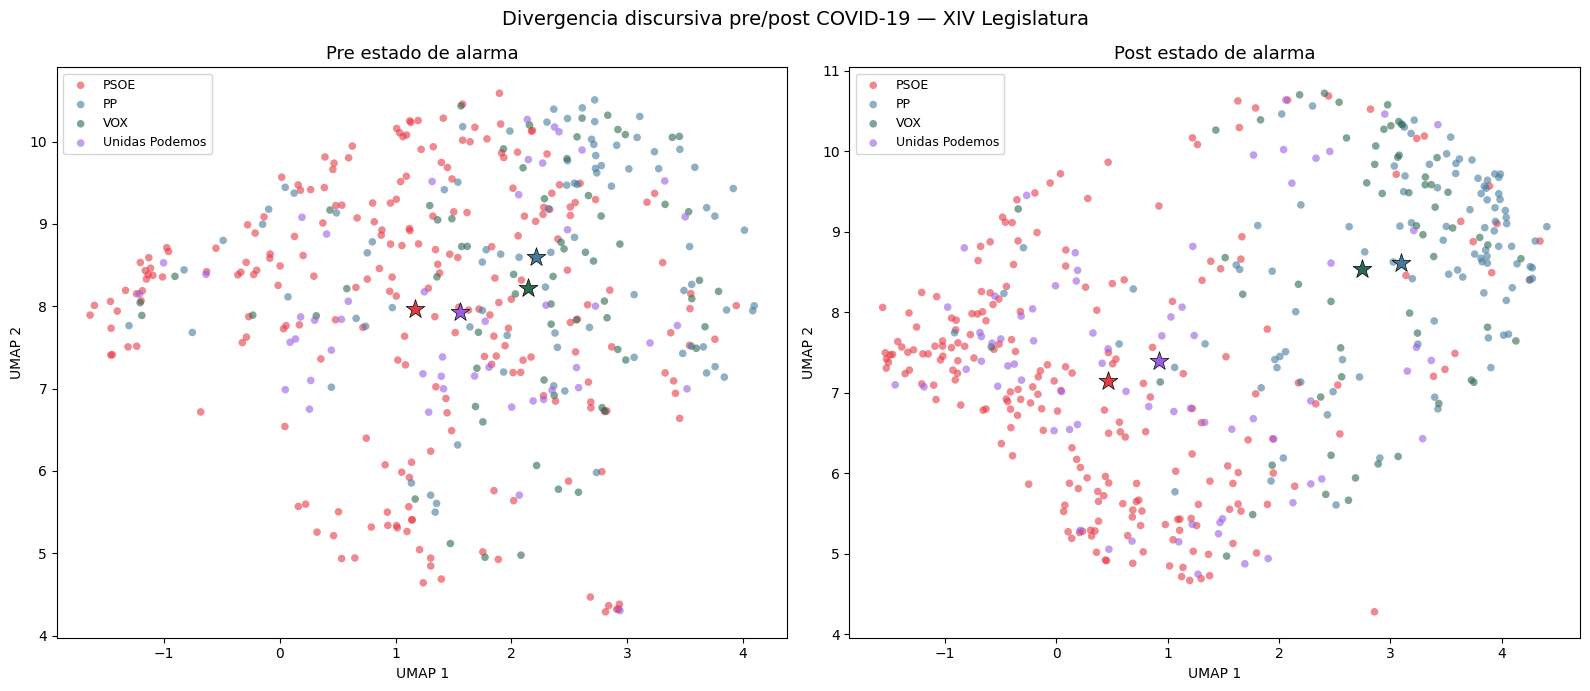

In [ ]:
# ============================================================
# ANÁLISIS: UMAP + visualización
# ============================================================

# Me quedo solo con los cuatro partidos principales para representar el espacio discursivo
mask = df["partido"].isin(PARTIDOS_PRINCIPALES)
emb_subset = embeddings[mask]
df_subset  = df[mask].reset_index(drop=True)

# Aplico UMAP para reducir los embeddings a dos dimensiones y poder visualizarlos
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb_2d  = reducer.fit_transform(emb_subset)

df_subset["umap_x"] = emb_2d[:, 0]
df_subset["umap_y"] = emb_2d[:, 1]

# Defino los colores que voy a usar para cada partido
COLORES = {"PSOE": "#E63946", "PP": "#457B9D", "VOX": "#2D6A4F", "Unidas Podemos": "#9B5DE5"}

# Creo un panel con dos gráficos: pre y post estado de alarma
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, periodo, titulo in zip(axes, ["pre", "post"],
                                ["Pre estado de alarma", "Post estado de alarma"]):
    sub = df_subset[df_subset["period"] == periodo]

    # Represento cada intervención como un punto en el espacio bidimensional
    for partido in PARTIDOS_PRINCIPALES:
        mask_p = sub["partido"] == partido
        ax.scatter(sub[mask_p]["umap_x"], sub[mask_p]["umap_y"],
                   c=COLORES[partido], label=partido,
                   alpha=0.6, s=30, edgecolors="none")

    # Marco también el centro visual de cada partido en el mapa UMAP
    for partido in PARTIDOS_PRINCIPALES:
        mask_p = sub["partido"] == partido
        cx = sub[mask_p]["umap_x"].mean()
        cy = sub[mask_p]["umap_y"].mean()
        ax.scatter(cx, cy, c=COLORES[partido], s=200, marker="*",
                   edgecolors="black", linewidths=0.5, zorder=5)
    ax.set_title(titulo, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.suptitle("Divergencia discursiva pre/post COVID-19 — XIV Legislatura", fontsize=14)
plt.tight_layout()
plt.savefig("umap_divergencia.png", dpi=150, bbox_inches="tight")
plt.show()

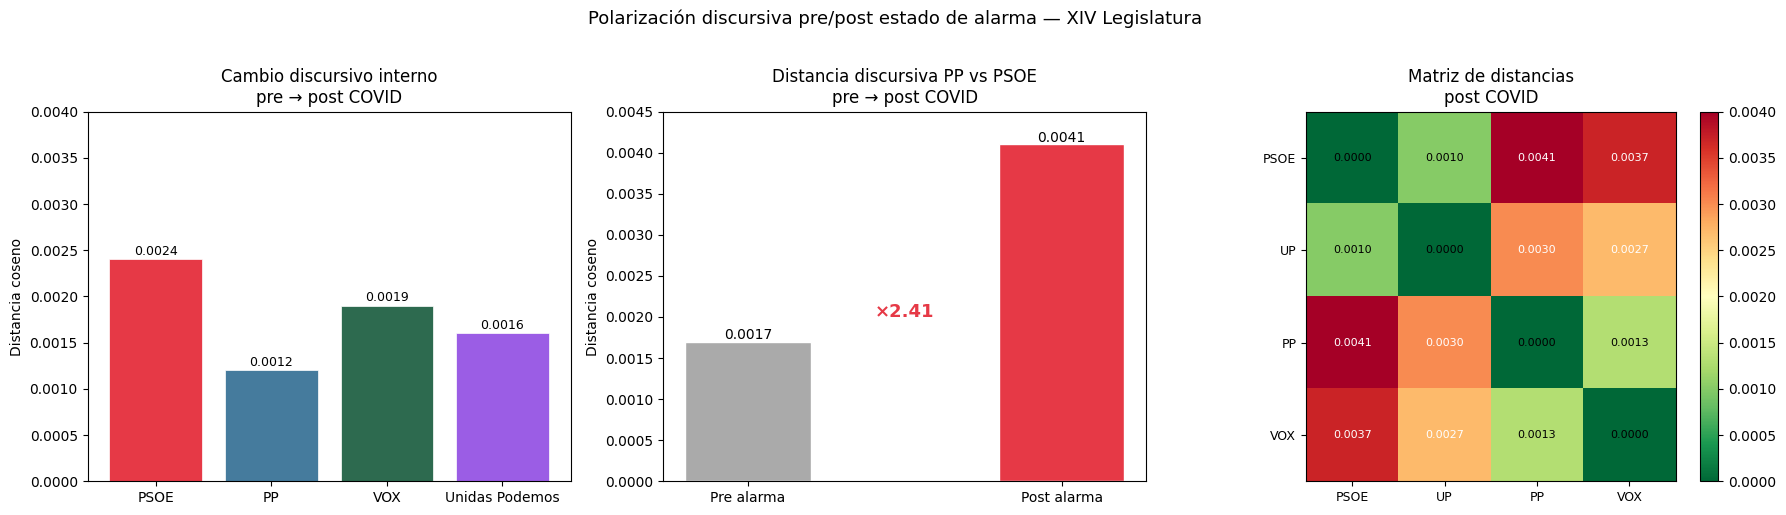


=== Tests de permutaciones extendidos ===

  Cambio interno PSOE             dist=0.0024  p=0.0000  ratio=12.6x  ✅ p<0.05
  Cambio interno VOX              dist=0.0019  p=0.0000  ratio=3.1x  ✅ p<0.05
  VOX vs PSOE post                dist=0.0037  p=0.0000  ratio=9.8x  ✅ p<0.05
  PP vs VOX post                  dist=0.0013  p=0.0000  ratio=2.6x  ✅ p<0.05


In [ ]:
# ============================================================
# ANÁLISIS: Visualización de distancias
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Creo una figura con tres paneles para resumir los principales resultados de polarización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Cambio interno pre-->post por partido
partidos  = ["PSOE", "PP", "VOX", "Unidas Podemos"]
distancias = [0.0024, 0.0012, 0.0019, 0.0016]
colores    = ["#E63946", "#457B9D", "#2D6A4F", "#9B5DE5"]

# Represento cuánto se desplaza el centroide de cada partido entre el período pre y el post
axes[0].bar(partidos, distancias, color=colores, edgecolor="white", linewidth=0.5)
axes[0].set_title("Cambio discursivo interno\npre → post COVID", fontsize=12)
axes[0].set_ylabel("Distancia coseno")
axes[0].set_ylim(0, 0.004)
for i, v in enumerate(distancias):
    axes[0].text(i, v + 0.00005, f"{v:.4f}", ha="center", fontsize=9)

# Gráfico 2: PP vs PSOE pre y post
periodos = ["Pre alarma", "Post alarma"]
dists_pp_psoe = [0.0017, 0.0041]
bar_colors = ["#aaaaaa", "#E63946"]

# Comparo visualmente la distancia entre PP y PSOE antes y después del estado de alarma
axes[1].bar(periodos, dists_pp_psoe, color=bar_colors, edgecolor="white", width=0.4)
axes[1].set_title("Distancia discursiva PP vs PSOE\npre → post COVID", fontsize=12)
axes[1].set_ylabel("Distancia coseno")
axes[1].set_ylim(0, 0.0045)
for i, v in enumerate(dists_pp_psoe):
    axes[1].text(i, v + 0.00003, f"{v:.4f}", ha="center", fontsize=10)
axes[1].annotate("×2.41", xy=(0.5, 0.0020), fontsize=13,
                 ha="center", color="#E63946", fontweight="bold")

# Gráfico 3: Heatmap matriz de distancias post
# Orden: PSOE, UP, PP, VOX

matriz = np.array([
    [0.0000, 0.0010, 0.0041, 0.0037],
    [0.0010, 0.0000, 0.0030, 0.0027],
    [0.0041, 0.0030, 0.0000, 0.0013],
    [0.0037, 0.0027, 0.0013, 0.0000],
])

partidos = ["PSOE", "UP", "PP", "VOX"]

# Muestro en un mapa de calor la distancia entre todos los partidos en el período post
im = axes[2].imshow(matriz, cmap="RdYlGn_r", vmin=0, vmax=0.004)

axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels(partidos, fontsize=9)
axes[2].set_yticklabels(partidos, fontsize=9)
axes[2].set_title("Matriz de distancias\npost COVID", fontsize=12)

for i in range(4):
    for j in range(4):
        axes[2].text(
            j, i, f"{matriz[i, j]:.4f}",
            ha="center", va="center", fontsize=8,
            color="white" if matriz[i, j] > 0.002 else "black"
        )

plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.suptitle("Polarización discursiva pre/post estado de alarma — XIV Legislatura",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("distancias_polarizacion.png", dpi=150, bbox_inches="tight")
plt.show()

pares_test = [
    ("PSOE", "pre",  "PSOE", "post",  "Cambio interno PSOE"),
    ("VOX",  "pre",  "VOX",  "post",  "Cambio interno VOX"),
    ("VOX",  "post", "PSOE", "post",  "VOX vs PSOE post"),
    ("PP",   "post", "VOX",  "post",  "PP vs VOX post"),
]

print("\n=== Tests de permutaciones extendidos ===\n")
for p1, per1, p2, per2, etiqueta in pares_test:
    idx1 = df[(df["partido"] == p1) & (df["period"] == per1)].index
    idx2 = df[(df["partido"] == p2) & (df["period"] == per2)].index
    emb1, emb2 = embeddings[idx1], embeddings[idx2]
    todos = np.vstack([emb1, emb2])
    n1 = len(emb1)

    # Calculo la distancia observada entre los dos grupos comparados
    dist_obs = 1 - cosine_similarity([emb1.mean(axis=0)], [emb2.mean(axis=0)])[0][0]

    # Genero la distribución nula con 1000 permutaciones aleatorias
    np.random.seed(42)
    dist_perm = []
    for _ in range(1000):
        perm = np.random.permutation(len(todos))
        c1 = todos[perm[:n1]].mean(axis=0)
        c2 = todos[perm[n1:]].mean(axis=0)
        dist_perm.append(1 - cosine_similarity([c1], [c2])[0][0])

    # Calculo el p-valor y el ratio frente a la media de las permutaciones
    p_val = np.mean(np.array(dist_perm) >= dist_obs)
    ratio = dist_obs / np.mean(dist_perm)   # effect size
    sig   = "✅ p<0.05" if p_val < 0.05 else "❌ no sig."
    print(f"  {etiqueta:30s}  dist={dist_obs:.4f}  p={p_val:.4f}  "
          f"ratio={ratio:.1f}x  {sig}")

In [ ]:
# ============================================================
# Test de permutaciones: ¿es significativo el aumento PP vs PSOE?
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Fijo la distancia observada entre PP y PSOE en el período post
dist_observada = 0.0041

# Selecciono las intervenciones de PP y PSOE en el período post
idx_pp_post   = df[(df["partido"]=="PP")   & (df["period"]=="post")].index
idx_psoe_post = df[(df["partido"]=="PSOE") & (df["period"]=="post")].index

emb_pp_post   = embeddings[idx_pp_post]
emb_psoe_post = embeddings[idx_psoe_post]

# Uno ambos grupos para construir la distribución nula mediante permutaciones
todos = np.vstack([emb_pp_post, emb_psoe_post])
n_pp  = len(emb_pp_post)
n_total = len(todos)

# Genero 1000 permutaciones aleatorias y recalculo la distancia en cada una
np.random.seed(42)
dist_permutadas = []
for _ in range(1000):
    perm = np.random.permutation(n_total)
    c1 = todos[perm[:n_pp]].mean(axis=0)
    c2 = todos[perm[n_pp:]].mean(axis=0)
    dist_permutadas.append(1 - cosine_similarity([c1], [c2])[0][0])

# Calculo el p-valor comparando la distancia observada con la distribución permutada
p_valor = np.mean(np.array(dist_permutadas) >= dist_observada)
print(f"Distancia observada: {dist_observada:.4f}")
print(f"Media permutaciones: {np.mean(dist_permutadas):.4f}")
print(f"p-valor:             {p_valor:.4f}")
print(f"Significativo (p<0.05): {p_valor < 0.05}")

Distancia observada: 0.0041
Media permutaciones: 0.0003
p-valor:             0.0000
Significativo (p<0.05): True


=== Distancia de cada partido al centroide global ===

  PSOE                 [pre]  dist=0.00089  (n=229)
  PSOE                 [post]  dist=0.00166  (n=220)
  PP                   [pre]  dist=0.00076  (n=86)
  PP                   [post]  dist=0.00124  (n=101)
  VOX                  [pre]  dist=0.00071  (n=65)
  VOX                  [post]  dist=0.00117  (n=57)
  Unidas Podemos       [pre]  dist=0.00080  (n=48)
  Unidas Podemos       [post]  dist=0.00087  (n=72)

=== Cambio en polarización pre→post ===

  PSOE                  Δ=+0.00077  ↑ AUMENTA
  PP                    Δ=+0.00048  ↑ AUMENTA
  VOX                   Δ=+0.00046  ↑ AUMENTA
  Unidas Podemos        Δ=+0.00007  ↑ AUMENTA


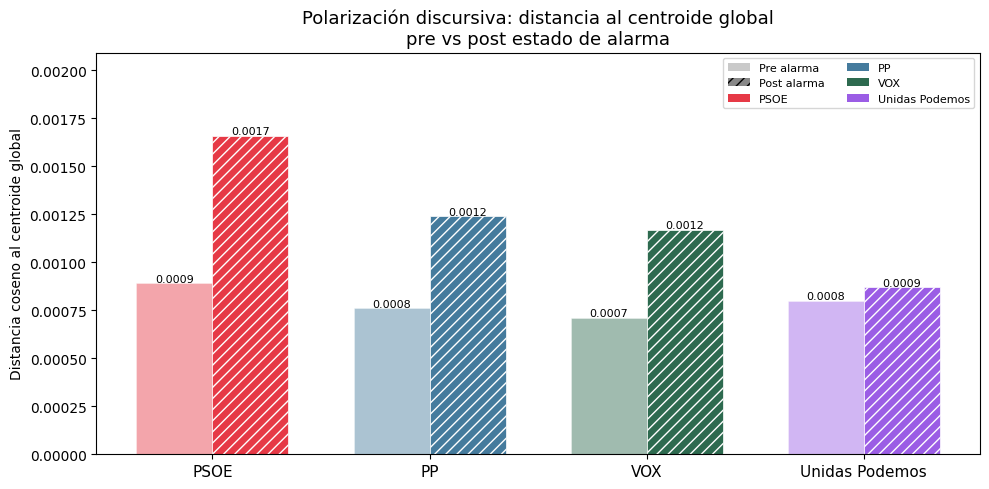

Usando reducción UMAP existente.


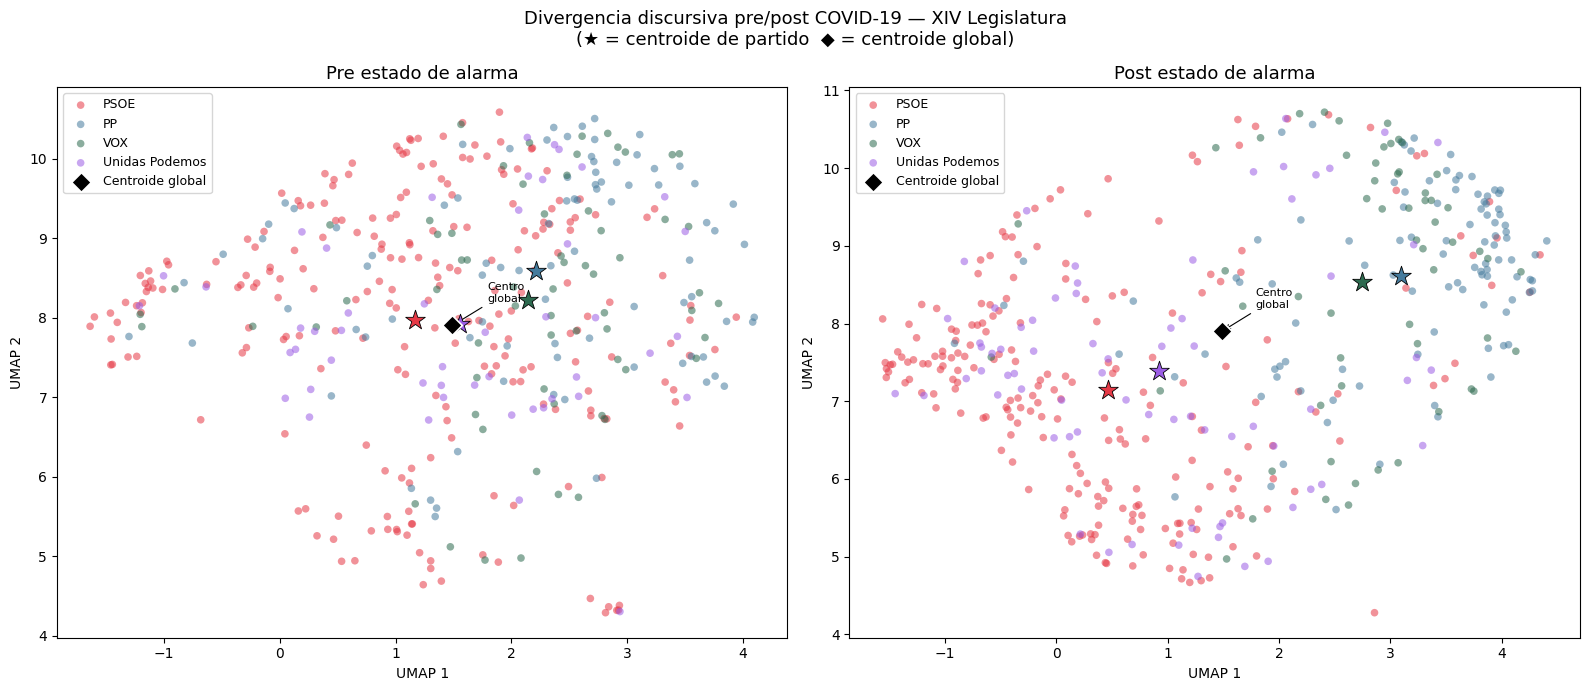

In [ ]:
# ============================================================
# ANÁLISIS: Distancia de cada partido al centroide global
# ============================================================
# Polarización = qué tan lejos está cada partido del "centro"

COLORES = {
    "PSOE": "#E63946", "PP": "#457B9D",
    "VOX": "#2D6A4F", "Unidas Podemos": "#9B5DE5"
}
PARTIDOS_PRINCIPALES = ["PSOE", "PP", "VOX", "Unidas Podemos"]

# Calculo un centroide global equiponderado, dando el mismo peso a cada partido
centroide_global = np.mean(
    [embeddings[df[df["partido"] == p].index].mean(axis=0)
     for p in PARTIDOS_PRINCIPALES],
    axis=0
)

print("=== Distancia de cada partido al centroide global ===\n")

# Calculo la distancia de cada partido al centroide global en pre y post
resultados_global = []
for partido in PARTIDOS_PRINCIPALES:
    for periodo in ["pre", "post"]:
        idx = df[(df["partido"] == partido) & (df["period"] == periodo)].index
        if len(idx) == 0:
            continue
        c_partido = embeddings[idx].mean(axis=0)
        dist = 1 - cosine_similarity([c_partido], [centroide_global])[0][0]
        resultados_global.append({
            "partido": partido,
            "periodo": periodo,
            "n_discursos": len(idx),
            "dist_centroide_global": round(dist, 5)
        })
        print(f"  {partido:20s} [{periodo}]  dist={dist:.5f}  (n={len(idx)})")

df_polar = pd.DataFrame(resultados_global)

# Cambio en polarización pre --> post
print("\n=== Cambio en polarización pre→post ===\n")
for partido in PARTIDOS_PRINCIPALES:
    sub = df_polar[df_polar["partido"] == partido].set_index("periodo")
    if "pre" in sub.index and "post" in sub.index:
        delta = sub.loc["post", "dist_centroide_global"] - sub.loc["pre", "dist_centroide_global"]
        signo = "↑ AUMENTA" if delta > 0 else "↓ DISMINUYE"
        print(f"  {partido:20s}  Δ={delta:+.5f}  {signo}")


# Gráfico 1: Barras agrupadas
# Represento en barras la distancia al centroide global en pre y post para cada partido
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(PARTIDOS_PRINCIPALES))
width = 0.35
PATRONES = {"pre": "", "post": "///"}

for i, periodo in enumerate(["pre", "post"]):
    vals = [
        df_polar[(df_polar["partido"] == p) & (df_polar["periodo"] == periodo)]["dist_centroide_global"].values[0]
        for p in PARTIDOS_PRINCIPALES
    ]
    colores_barras = [COLORES[p] for p in PARTIDOS_PRINCIPALES]
    alphas = [1.0 if periodo == "post" else 0.45 for _ in PARTIDOS_PRINCIPALES]

    for j, (v, col, alpha) in enumerate(zip(vals, colores_barras, alphas)):
        bar = ax.bar(
            x[j] + i * width, v, width,
            color=col, alpha=alpha,
            edgecolor="white", linewidth=0.5,
            hatch=PATRONES[periodo],
            label=f"{PARTIDOS_PRINCIPALES[j]} ({periodo})" if i == 0 else None
        )
        ax.text(x[j] + i * width, v + 0.000008,
                f"{v:.4f}", ha="center", fontsize=8)

# Leyenda de período
from matplotlib.patches import Patch
legend_elementos = [
    Patch(facecolor="#888888", alpha=0.45, label="Pre alarma"),
    Patch(facecolor="#888888", alpha=1.0,  hatch="///", label="Post alarma"),
] + [Patch(facecolor=COLORES[p], label=p) for p in PARTIDOS_PRINCIPALES]

ax.set_xticks(x + width / 2)
ax.set_xticklabels(PARTIDOS_PRINCIPALES, fontsize=11)
ax.set_ylabel("Distancia coseno al centroide global")
ax.set_title("Polarización discursiva: distancia al centroide global\npre vs post estado de alarma", fontsize=13)
ax.legend(handles=legend_elementos, fontsize=8, ncol=2, loc="upper right")
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig("polarizacion_centroide_global.png", dpi=150, bbox_inches="tight")
plt.show()


# Gráfico 2: UMAP con centroide global marcado
# Reutilizo la reducción UMAP anterior si ya está calculada; si no, la recalculo
try:
    _ = emb_2d
    print("Usando reducción UMAP existente.")
except NameError:
    print("Recalculando UMAP...")
    mask_umap = df["partido"].isin(PARTIDOS_PRINCIPALES)
    emb_subset = embeddings[mask_umap]
    df_subset  = df[mask_umap].reset_index(drop=True)
    reducer    = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    emb_2d     = reducer.fit_transform(emb_subset)
    df_subset["umap_x"] = emb_2d[:, 0]
    df_subset["umap_y"] = emb_2d[:, 1]

# Proyectar el centroide global al mismo espacio UMAP
# (se proyecta como un punto nuevo sobre el reducer ya entrenado)
centroide_global_2d = np.array([
    df_subset["umap_x"].mean(),
    df_subset["umap_y"].mean()
])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, periodo, titulo in zip(
    axes,
    ["pre", "post"],
    ["Pre estado de alarma", "Post estado de alarma"]
):
    sub = df_subset[df_subset["period"] == periodo]

    # Puntos de cada partido
    for partido in PARTIDOS_PRINCIPALES:
        mask_p = sub["partido"] == partido
        ax.scatter(
            sub[mask_p]["umap_x"], sub[mask_p]["umap_y"],
            c=COLORES[partido], label=partido,
            alpha=0.55, s=30, edgecolors="none"
        )

    # Centroides de partido (★)
    for partido in PARTIDOS_PRINCIPALES:
        mask_p = sub["partido"] == partido
        cx = sub[mask_p]["umap_x"].mean()
        cy = sub[mask_p]["umap_y"].mean()
        ax.scatter(cx, cy, c=COLORES[partido], s=220, marker="*",
                   edgecolors="black", linewidths=0.6, zorder=5)

    # Centroide GLOBAL (⬟)
    ax.scatter(
        centroide_global_2d[0], centroide_global_2d[1],
        c="black", s=100, marker="D",
        edgecolors="white", linewidths=1.2,
        zorder=6, label="Centroide global"
    )
    ax.annotate(
        "Centro\nglobal",
        xy=(centroide_global_2d[0], centroide_global_2d[1]),
        xytext=(centroide_global_2d[0] + 0.3, centroide_global_2d[1] + 0.3),
        fontsize=8, color="black",
        arrowprops=dict(arrowstyle="->", color="black", lw=0.8)
    )

    ax.set_title(titulo, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.suptitle(
    "Divergencia discursiva pre/post COVID-19 — XIV Legislatura\n"
    "(★ = centroide de partido  ◆ = centroide global)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("umap_con_centroide_global.png", dpi=150, bbox_inches="tight")
plt.show()

 Nota: el centroide_global_2d es el centro visual de los 4 partidos representados. El centroide_global en 768D incluye todos los partidos.
La ligera discrepancia es debido a la reducción dimensional para relaizar el mapa visual

=== Estadísticas de ventanas incluidas (n≥5) ===
Ventanas x partido en el gráfico: 48
Mínimo de discursos por celda incluida: 5
Media de discursos por celda incluida:  17.6
Partidos sin datos suficientes en alguna ventana: {'PP': 12, 'PSOE': 14, 'Unidas Podemos': 11, 'VOX': 11}

Referencia global por partido (línea horizontal):
  PP                  : 0.00102
  PSOE                : 0.00127
  Unidas Podemos      : 0.00084
  VOX                 : 0.00092


/tmp/ipykernel_1646/1060100474.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["dist_centroide_global"], weights=x["n_discursos"]))


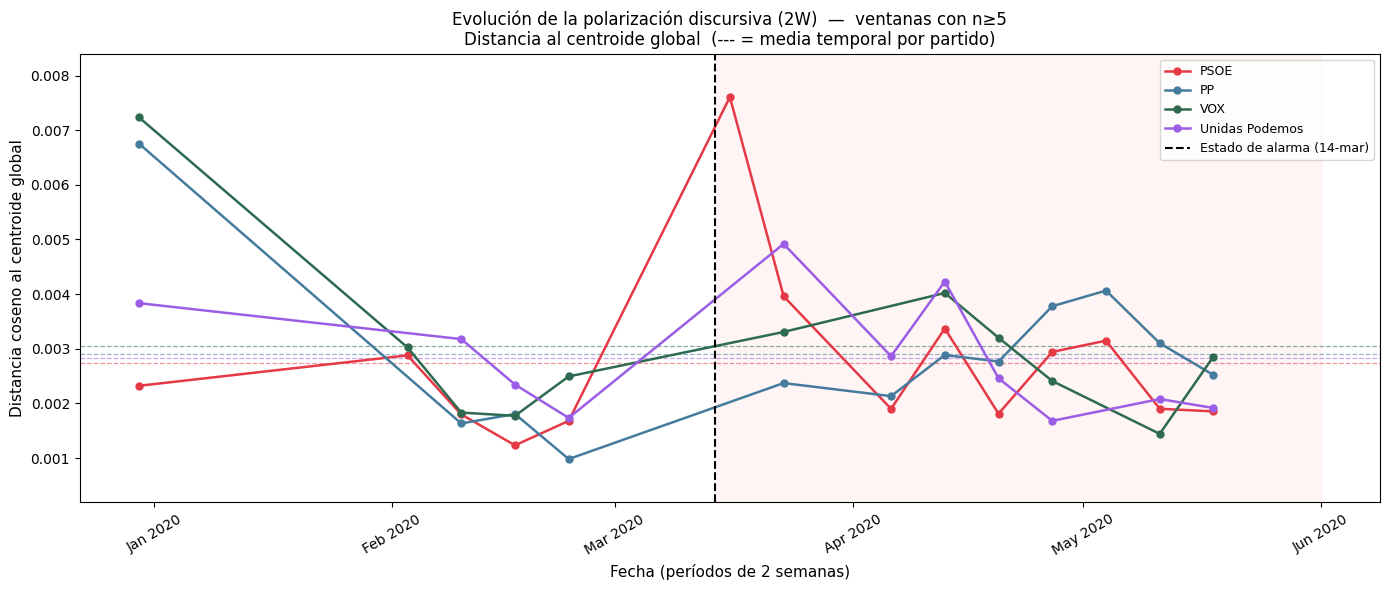

In [ ]:
# ============================================================
# ANÁLISIS: Evolución temporal en períodos de 2 semanas
# ============================================================
import matplotlib.dates as mdates

# Frecuencia temporal del análisis:
# "2W" = ventanas de 2 semanas
FREQ   = "2W"

# Umbral mínimo de discursos por partido y ventana
# para considerar esa observación en el gráfico
N_MIN  = 5

df["fecha_dt"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.dropna(subset=["fecha_dt"]).reset_index(drop=True)
# Para cada intervención, asignamos el inicio de su período temporal
# (en este caso, la fecha de inicio de su ventana de 2 semanas)
df["periodo_tiempo"] = df["fecha_dt"].dt.to_period(FREQ).dt.start_time


df_temp_base = df.copy()
df_temp_base["periodo_tiempo"] = df_temp_base["fecha_dt"].dt.to_period(FREQ).dt.start_time

#  Calcular distancias por ventana
resultados_temp = []
for partido in PARTIDOS_PRINCIPALES:
    for ventana, grupo in df[df["partido"] == partido].groupby("periodo_tiempo"):
      # Filtramos ventanas con pocos discursos para evitar
        # centroides poco representativos o muy inestable
        if len(grupo) < N_MIN:
            continue
        idx = grupo.index
        # Centroide del partido en esa ventana:
        # media de los embeddings de los discursos del grupo
        c   = embeddings[idx].mean(axis=0)
        dist = 1 - cosine_similarity([c], [centroide_global])[0][0]
        resultados_temp.append({
            "partido": partido,
            "ventana": ventana,
            "n":       len(grupo),
            "dist_global": dist
        })

df_temp = pd.DataFrame(resultados_temp)

# Estadísticas DESPUÉS del filtro
conteo_filtrado = df_temp.groupby(["ventana","partido"])["n"].sum().unstack(fill_value=0)
print(f"=== Estadísticas de ventanas incluidas (n≥{N_MIN}) ===")
print(f"Ventanas x partido en el gráfico: {len(df_temp)}")
print(f"Mínimo de discursos por celda incluida: {df_temp['n'].min()}")
print(f"Media de discursos por celda incluida:  {df_temp['n'].mean():.1f}")
print(f"Partidos sin datos suficientes en alguna ventana: "
      f"{df_temp.groupby('partido')['ventana'].count().to_dict()}")

# Líneas de referencia: distancia media de cada partido
# al centroide global sobre TODO su corpus

try:
    _ = df_polar
except NameError:
    rows = []
    for p in PARTIDOS_PRINCIPALES:
        idx = df[df["partido"] == p].index
        c   = embeddings[idx].mean(axis=0)
        d   = 1 - cosine_similarity([c], [centroide_global])[0][0]
        rows.append({"partido": p, "dist_media_global": d})
    df_polar_ref = pd.DataFrame(rows)
else:
    # df_polar tiene pre y post —-> tomamos la media ponderada global
    df_polar_ref = (
        df_polar.groupby("partido")
        .apply(lambda x: np.average(x["dist_centroide_global"], weights=x["n_discursos"]))
        .reset_index(name="dist_media_global")
    )

ref = df_polar_ref.set_index("partido")["dist_media_global"].to_dict()
print("\nReferencia global por partido (línea horizontal):")
for p, v in ref.items():
    print(f"  {p:20s}: {v:.5f}")

# Gráfico de visualización de la evolución temporal
FECHA_ALARMA = pd.Timestamp("2020-03-14")

fig, ax = plt.subplots(figsize=(14, 6))

for partido in PARTIDOS_PRINCIPALES:
    sub = df_temp[df_temp["partido"] == partido].sort_values("ventana")
    if sub.empty:
        continue

    # Serie temporal
    ax.plot(sub["ventana"], sub["dist_global"],
            marker="o", markersize=5, linewidth=1.8,
            color=COLORES[partido], label=partido, zorder=4)

    # Línea de referencia = media de la serie temporal del partido
    media_partido = sub["dist_global"].mean()
    ax.axhline(
        media_partido,
        color=COLORES[partido],
        linewidth=0.9, linestyle="--", alpha=0.55,
        zorder=2
    )

# Estado de alarma
ax.axvline(FECHA_ALARMA, color="black", linestyle="--",
           linewidth=1.5, label="Estado de alarma (14-mar)", zorder=5)

ax.axvspan(FECHA_ALARMA, df_temp["ventana"].max() + pd.Timedelta(days=14),
           alpha=0.04, color="red", zorder=0)

y_max = df_temp["dist_global"].max()
y_min = df_temp["dist_global"].min()
margen = (y_max - y_min) * 0.12
ax.set_ylim(max(0, y_min - margen), y_max + margen)

ax.set_xlabel("Fecha (períodos de 2 semanas)", fontsize=11)
ax.set_ylabel("Distancia coseno al centroide global", fontsize=11)
ax.set_title(
    f"Evolución de la polarización discursiva ({FREQ})  —  ventanas con n≥{N_MIN}\n"
    "Distancia al centroide global  (--- = media temporal por partido)",
    fontsize=12
)
ax.legend(fontsize=9, loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("evolucion_temporal_polarizacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# ANÁLISIS 5: Discursos más cercanos y más lejanos al centroide
# de su propio partido — ¿quiénes son los outliers?
# ============================================================
# Para este análisis se excluyen las intervenciones con role institucional
# de la Mesa del Congreso (presidencia, vicepresidencias, secretarías),
# ya que son procedimentales y no reflejan posición política del orador.

TOP_N = 5
ROLES_MESA = ["PRESIDENTE", "PRESIDENTA",
              "VICEPRESIDENTE", "VICEPRESIDENTA",
              "SECRETARIO", "SECRETARIA"]

# Filtrado local: subset sin intervenciones procedimentales de la Mesa
mask_no_mesa = ~df["role"].astype(str).str.upper().isin(ROLES_MESA)
df_an5 = df[mask_no_mesa].copy()
df_an5["dist_centroide_partido"] = np.nan

print(f"Intervenciones excluidas por role de Mesa: {(~mask_no_mesa).sum()}")
print(f"Corpus para análisis de outliers: {len(df_an5)}")

for partido in PARTIDOS_PRINCIPALES:
    for periodo in ["pre", "post"]:
        idx = df_an5[(df_an5["partido"] == partido) & (df_an5["period"] == periodo)].index
        if len(idx) < 2:
            continue
        # Centroide del partido en ese período (recalculado sin Mesa)
        c = embeddings[idx].mean(axis=0)
        # Distancia de cada discurso al centroide de su propio partido
        sims = cosine_similarity(embeddings[idx], [c]).flatten()
        dists = 1 - sims
        df_an5.loc[idx, "dist_centroide_partido"] = dists

resumen_outliers = []

for partido in PARTIDOS_PRINCIPALES:
    print(f"\n{'='*60}")
    print(f"  {partido}")
    print(f"{'='*60}")
    for periodo in ["pre", "post"]:
        sub = df_an5[(df_an5["partido"] == partido) &
                     (df_an5["period"] == periodo) &
                     (df_an5["dist_centroide_partido"].notna())].copy()
        # Los más cercanos al centroide son los más representativos;
        # los más lejanos funcionan como outliers discursivos
        sub = sub.sort_values("dist_centroide_partido")

        print(f"\n  [{periodo.upper()}]  (n={len(sub)})")
        print(f"  {'--- CERCANOS AL CENTROIDE (más representativos) ---':^55}")
        for _, row in sub.head(TOP_N).iterrows():
            texto_corto = str(row.get("intervention", ""))[:120].replace("\n", " ")
            print(f"    Dist={row['dist_centroide_partido']:.5f} | {row.get('oradorx','?')} | {texto_corto}...")

        print(f"\n  {'--- LEJANOS AL CENTROIDE (outliers) ---':^55}")
        for _, row in sub.tail(TOP_N).iterrows():
            texto_corto = str(row.get("intervention", ""))[:120].replace("\n", " ")
            print(f"    Dist={row['dist_centroide_partido']:.5f} | {row.get('oradorx','?')} | {texto_corto}...")

        resumen_outliers.append({
            "partido":            partido,
            "periodo":            periodo,
            "orador_mas_central": sub.head(1)["oradorx"].values[0] if len(sub) > 0 else None,
            "orador_mas_outlier": sub.tail(1)["oradorx"].values[0] if len(sub) > 0 else None,
            "dist_min":           round(sub["dist_centroide_partido"].min(), 5),
            "dist_max":           round(sub["dist_centroide_partido"].max(), 5),
            "dist_media":         round(sub["dist_centroide_partido"].mean(), 5),
        })

df_outliers_resumen = pd.DataFrame(resumen_outliers)

print("\n\n" + "="*60)
print("RESUMEN: oradores más centrales y más outliers")
print("="*60)
print(df_outliers_resumen.to_string(index=False))

print("\n\n" + "="*60)
print("¿CAMBIA EL PERFIL DE OUTLIER pre → post?")
print("="*60)
for partido in PARTIDOS_PRINCIPALES:
    sub = df_outliers_resumen[df_outliers_resumen["partido"] == partido].set_index("periodo")
    if "pre" in sub.index and "post" in sub.index:
        pre_out   = sub.loc["pre",  "orador_mas_outlier"]
        post_out  = sub.loc["post", "orador_mas_outlier"]
        pre_cent  = sub.loc["pre",  "orador_mas_central"]
        post_cent = sub.loc["post", "orador_mas_central"]
        cambio    = "⚠ CAMBIA" if pre_out != post_out else "= MISMO"
        print(f"\n  {partido}")
        print(f"    Outlier     pre: {pre_out}  →  post: {post_out}   [{cambio}]")
        print(f"    Más central pre: {pre_cent}  →  post: {post_cent}")


# Guardar y descargar el resumen de outliers
from google.colab import files

with open("/content/output_analisis5.txt", "w", encoding="utf-8") as f:
    f.write("RESUMEN OUTLIERS POR PARTIDO\n")
    f.write("="*60 + "\n\n")
    f.write(df_outliers_resumen.to_string(index=False))
    f.write("\n\n" + "="*60 + "\n")
    f.write("¿CAMBIA EL PERFIL DE OUTLIER pre → post?\n")
    f.write("="*60 + "\n\n")
    for partido in PARTIDOS_PRINCIPALES:
        sub = df_outliers_resumen[df_outliers_resumen["partido"] == partido].set_index("periodo")
        if "pre" in sub.index and "post" in sub.index:
            pre_out  = sub.loc["pre",  "orador_mas_outlier"]
            post_out = sub.loc["post", "orador_mas_outlier"]
            pre_cent = sub.loc["pre",  "orador_mas_central"]
            post_cent= sub.loc["post", "orador_mas_central"]
            cambio   = "⚠ CAMBIA" if pre_out != post_out else "= MISMO"
            f.write(f"\n  {partido}\n")
            f.write(f"    Outlier     pre: {pre_out}  →  post: {post_out}   [{cambio}]\n")
            f.write(f"    Más central pre: {pre_cent}  →  post: {post_cent}\n")

files.download("/content/output_analisis5.txt")
print(" Descargado")

Intervenciones excluidas por role de Mesa: 6
Corpus para análisis de outliers: 1465

  PSOE

  [PRE]  (n=229)
    --- CERCANOS AL CENTROIDE (más representativos) ---  
    Dist=0.00698 | DARIAS SAN SEBASTIÁN | Gracias, señora presidenta. Señorías, reconozco que tenía otro principio para esta intervención, pero escuchando lo que ...
    Dist=0.00719 | SÁNCHEZ PÉREZ-CASTEJÓN | Dice el señor Sayas que era la primera fuerza política en Navarra. ¿Y nosotros qué somos, la tercera fuerza política en ...
    Dist=0.00744 | SÁNCHEZ PÉREZ-CASTEJÓN | Señor Abascal, usted continúa diciendo que nosotros vertimos todo tipo de falsedades, que ustedes dicen la verdad. Le vo...
    Dist=0.00763 | MONTERO CUADRADO | Muchas gracias, señora presidenta. Señor Bel, le tengo que manifestar mi sorpresa, no ingenua, ante el hecho de que uste...
    Dist=0.00771 | SÁNCHEZ PÉREZ-CASTEJÓN | Muchas gracias, señorías. Gracias a todos los integrantes del Grupo Plural. Me voy a referir a todos y cada uno de ellos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Descargado


=== Dispersión interna de partidos (cohesión interna) ===

  PSOE                 [pre]  mean_dist=0.02264  std=0.01391  mean_pares=0.04496  (n=229)
  PSOE                 [post]  mean_dist=0.01640  std=0.01071  mean_pares=0.03268  (n=220)
  PP                   [pre]  mean_dist=0.01843  std=0.01077  mean_pares=0.03696  (n=86)
  PP                   [post]  mean_dist=0.01807  std=0.01426  mean_pares=0.03617  (n=101)
  VOX                  [pre]  mean_dist=0.01960  std=0.01491  mean_pares=0.03942  (n=65)
  VOX                  [post]  mean_dist=0.01379  std=0.01008  mean_pares=0.02789  (n=57)
  Unidas Podemos       [pre]  mean_dist=0.01887  std=0.01118  mean_pares=0.03818  (n=48)
  Unidas Podemos       [post]  mean_dist=0.01625  std=0.00998  mean_pares=0.03269  (n=72)

=== Cambio en dispersión interna pre→post ===

Partido                Δ mean_dist_centroide       Δ std    Δ mean_pares
  PSOE                  -0.00624  -0.00320  -0.01228
  PP                    -0.00036  +0.00349  -0.0

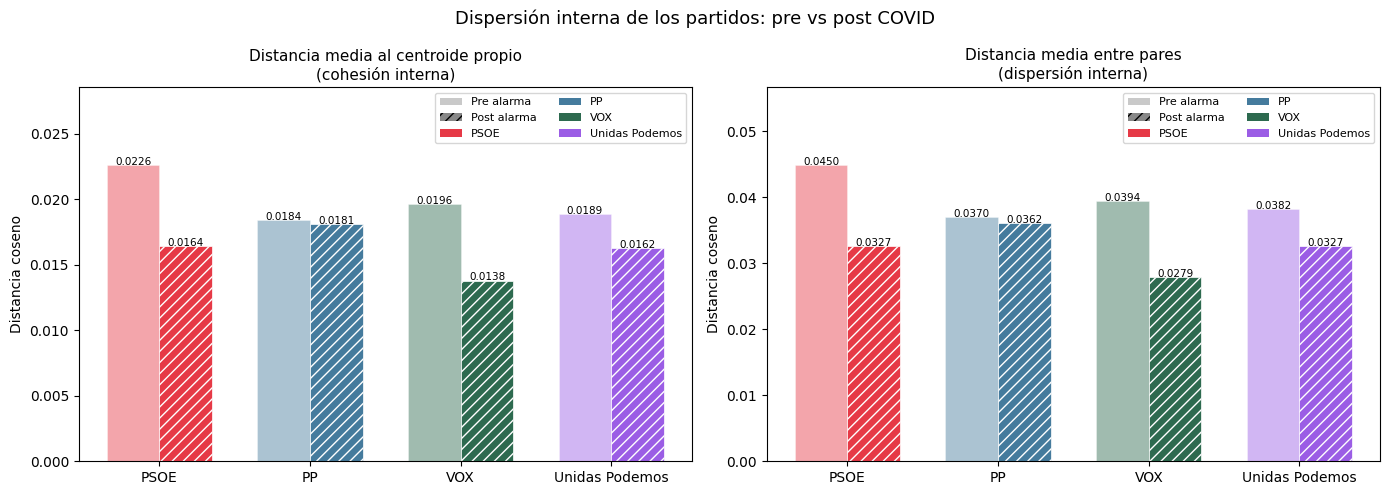


=== Significancia del cambio en cohesión interna (permutaciones) ===

Partido                Δ observado   p-valor    ratio         sig
-----------------------------------------------------------------
  PSOE                  -0.00624  0.0000     6.0x  ✅ p<0.05
  PP                    -0.00036  0.8550     0.2x  ❌ no sig.
  VOX                   -0.00581  0.0150     2.9x  ✅ p<0.05
  Unidas Podemos        -0.00262  0.2040     1.6x  ❌ no sig.


In [ ]:
# ============================================================
# ANÁLISIS 6: Dispersión interna de cada partido
# Dos métricas: (a) std de distancias al centroide propio
#               (b) distancia media entre todos los pares
# ============================================================
print("=== Dispersión interna de partidos (cohesión interna) ===\n")

from itertools import combinations
from matplotlib.patches import Patch

COLORES = {
    "PSOE":           "#E63946",
    "PP":             "#457B9D",
    "VOX":            "#2D6A4F",
    "Unidas Podemos": "#9B5DE5"
}
PATRONES = {"pre": "", "post": "///"}

resultados_dispersion = []

for partido in PARTIDOS_PRINCIPALES:
    for periodo in ["pre", "post"]:
        idx = df[(df["partido"] == partido) & (df["period"] == periodo)].index
        if len(idx) < 2:
            continue
        emb = embeddings[idx]
        c = emb.mean(axis=0)

        # Distancia de cada discurso al centroide de su partido
        dists_a_centroide = 1 - cosine_similarity(emb, [c]).flatten()
        std_centroide = dists_a_centroide.std()
        mean_centroide = dists_a_centroide.mean()

        # Distancia media entre todos los pares de discursos del grupo
        sims_pares = cosine_similarity(emb)
        mask_upper = np.triu(np.ones(sims_pares.shape, dtype=bool), k=1)
        dists_pares = 1 - sims_pares[mask_upper]
        mean_pares = dists_pares.mean()

        resultados_dispersion.append({
            "partido":             partido,
            "periodo":             periodo,
            "n":                   len(idx),
            "mean_dist_centroide": round(mean_centroide, 5),
            "std_dist_centroide":  round(std_centroide, 5),
            "mean_dist_pares":     round(mean_pares, 5)
        })
        print(f"  {partido:20s} [{periodo}]  mean_dist={mean_centroide:.5f}  "
              f"std={std_centroide:.5f}  mean_pares={mean_pares:.5f}  (n={len(idx)})")

df_disp = pd.DataFrame(resultados_dispersion)

# Cambio en dispersión pre --> post
print("\n=== Cambio en dispersión interna pre→post ===\n")
print(f"{'Partido':20s}  {'Δ mean_dist_centroide':>22}  {'Δ std':>10}  {'Δ mean_pares':>14}")
for partido in PARTIDOS_PRINCIPALES:
    sub = df_disp[df_disp["partido"] == partido].set_index("periodo")
    if "pre" in sub.index and "post" in sub.index:
        dm = sub.loc["post", "mean_dist_centroide"] - sub.loc["pre", "mean_dist_centroide"]
        ds = sub.loc["post", "std_dist_centroide"]  - sub.loc["pre", "std_dist_centroide"]
        dp = sub.loc["post", "mean_dist_pares"]     - sub.loc["pre", "mean_dist_pares"]
        print(f"  {partido:20s}  {dm:+.5f}  {ds:+.5f}  {dp:+.5f}")

# Visualización
metricas = [
    ("mean_dist_centroide", "Distancia media al centroide propio\n(cohesión interna)"),
    ("mean_dist_pares",     "Distancia media entre pares\n(dispersión interna)"),
]

x     = np.arange(len(PARTIDOS_PRINCIPALES))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metrica, titulo) in zip(axes, metricas):
    for i, periodo in enumerate(["pre", "post"]):
        vals = [
            df_disp[(df_disp["partido"] == p) & (df_disp["periodo"] == periodo)][metrica].values[0]
            for p in PARTIDOS_PRINCIPALES
        ]
        alpha = 0.45 if periodo == "pre" else 1.0

        for j, (v, partido) in enumerate(zip(vals, PARTIDOS_PRINCIPALES)):
            ax.bar(
                x[j] + i * width, v, width,
                color=COLORES[partido],
                alpha=alpha,
                edgecolor="white",
                linewidth=0.5,
                hatch=PATRONES[periodo]
            )
            ax.text(x[j] + i * width, v + 0.000005,
                    f"{v:.4f}", ha="center", fontsize=7.5)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(PARTIDOS_PRINCIPALES, fontsize=10)
    ax.set_ylabel("Distancia coseno")
    ax.set_title(titulo, fontsize=11)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

    legend_elementos = [
        Patch(facecolor="#888888", alpha=0.45, label="Pre alarma"),
        Patch(facecolor="#888888", alpha=1.0, hatch="///", label="Post alarma"),
    ] + [Patch(facecolor=COLORES[p], label=p) for p in PARTIDOS_PRINCIPALES]

    ax.legend(handles=legend_elementos, fontsize=8, ncol=2, loc="upper right")

plt.suptitle("Dispersión interna de los partidos: pre vs post COVID", fontsize=13)
plt.tight_layout()
plt.savefig("dispersion_interna.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# Test de permutaciones: ¿es significativo el cambio de
# dispersión interna pre-->post en cada partido?
# ============================================================
print("\n=== Significancia del cambio en cohesión interna (permutaciones) ===\n")
print(f"{'Partido':20s}  {'Δ observado':>12}  {'p-valor':>8}  {'ratio':>7}  {'sig':>10}")
print("-" * 65)

N_PERM = 1000
np.random.seed(42)

for partido in PARTIDOS_PRINCIPALES:
    idx_pre  = df[(df["partido"] == partido) & (df["period"] == "pre")].index
    idx_post = df[(df["partido"] == partido) & (df["period"] == "post")].index
    n_pre, n_post = len(idx_pre), len(idx_post)

    emb_pre  = embeddings[idx_pre]
    emb_post = embeddings[idx_post]
    todos    = np.vstack([emb_pre, emb_post])

    # Dispersión observada en cada período (distancia media al centroide propio)
    def mean_dist_to_centroid(emb):
        c = emb.mean(axis=0)
        return (1 - cosine_similarity(emb, [c]).flatten()).mean()

    disp_pre_obs  = mean_dist_to_centroid(emb_pre)
    disp_post_obs = mean_dist_to_centroid(emb_post)
    delta_obs     = disp_post_obs - disp_pre_obs  # negativo = más cohesión

    # Permutaciones
    deltas_perm = []
    for _ in range(N_PERM):
        perm = np.random.permutation(n_pre + n_post)
        d_pre  = mean_dist_to_centroid(todos[perm[:n_pre]])
        d_post = mean_dist_to_centroid(todos[perm[n_pre:]])
        deltas_perm.append(d_post - d_pre)

    deltas_perm = np.array(deltas_perm)
    # p-valor bilateral (¿cuántas permutaciones tienen un delta tan extremo?)
    p_val = np.mean(np.abs(deltas_perm) >= np.abs(delta_obs))
    ratio = abs(delta_obs) / (np.abs(deltas_perm).mean() + 1e-10)
    sig   = "✅ p<0.05" if p_val < 0.05 else "❌ no sig."

    print(f"  {partido:20s}  {delta_obs:+.5f}  {p_val:.4f}  {ratio:>6.1f}x  {sig}")


Centroide PSOE                 calculado sobre 449 intervenciones
Centroide PP                   calculado sobre 187 intervenciones
Centroide VOX                  calculado sobre 122 intervenciones
Centroide Unidas Podemos       calculado sobre 120 intervenciones

=== Distancias por ventana ===

       partido periodo  ventana  n  mean_dist  std_dist       se
          PSOE     pre        1 77   0.018771  0.012452 0.001419
          PSOE     pre        2 76   0.026414  0.016817 0.001929
          PSOE     pre        3 76   0.024400  0.014332 0.001644
          PSOE    post        1 74   0.016059  0.009948 0.001156
          PSOE    post        2 73   0.017455  0.010551 0.001235
          PSOE    post        3 73   0.017593  0.009787 0.001146
            PP     pre        1 29   0.018123  0.012855 0.002387
            PP     pre        2 29   0.021162  0.009905 0.001839
            PP     pre        3 28   0.017029  0.009296 0.001757
            PP    post        1 34   0.017285  0.0141

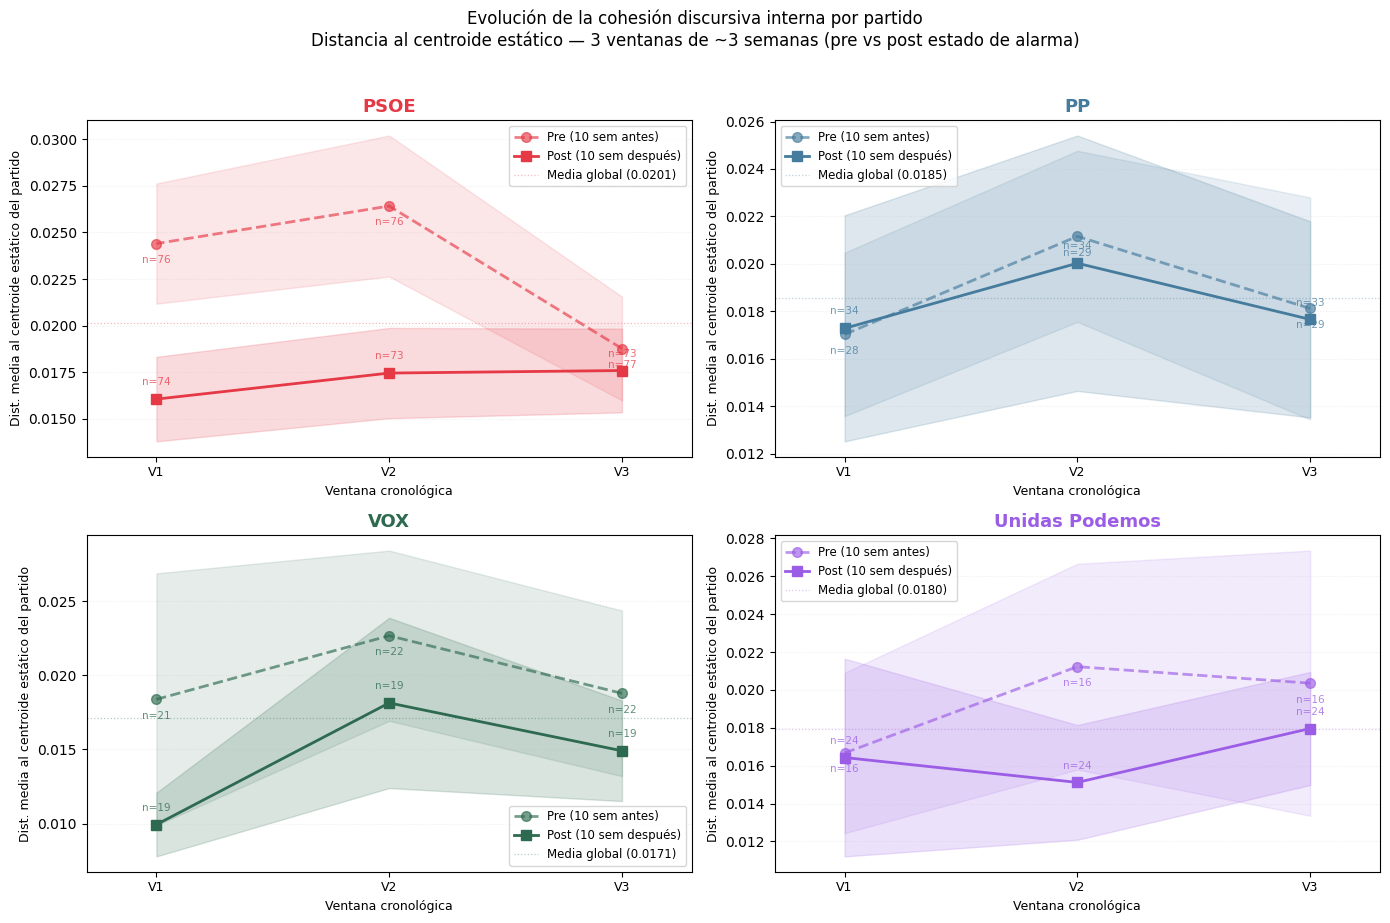


=== Cambio V1→V3 por partido y periodo ===

Partido              Periodo        V1        V2        V3     Δ V1→V3
-----------------------------------------------------------------
  PSOE                 pre     0.01877  0.02641  0.02440  +0.00563 ↑
  PSOE                 post    0.01606  0.01746  0.01759  +0.00153 ↑
  PP                   pre     0.01812  0.02116  0.01703  -0.00109 ↓
  PP                   post    0.01728  0.02003  0.01766  +0.00038 ↑
  VOX                  pre     0.01878  0.02268  0.01838  -0.00040 ↓
  VOX                  post    0.00993  0.01814  0.01491  +0.00498 ↑
  Unidas Podemos       pre     0.02036  0.02123  0.01667  -0.00369 ↓
  Unidas Podemos       post    0.01643  0.01511  0.01796  +0.00153 ↑


In [ ]:
# ============================================================
# ANÁLISIS TEMPORAL: cohesión interna por ventanas de ~3 semanas
# Centroide estático por partido (pre + post juntos)
# 3 ventanas: semanas 1-3 / 4-7 / 8-10
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

PARTIDOS_PRINCIPALES = ["PSOE", "PP", "VOX", "Unidas Podemos"]
N_VENTANAS = 3
colores = {
    "PSOE":           "#E63946",
    "PP":             "#457B9D",
    "VOX":            "#2D6A4F",
    "Unidas Podemos": "#9B5DE5"
}

# 1. Centroide estático por partido (todo el corpus, pre+post)
centroides_estaticos = {}
for partido in PARTIDOS_PRINCIPALES:
    idx = df[df["partido"] == partido].index
    centroides_estaticos[partido] = embeddings[idx].mean(axis=0)
    print(f"Centroide {partido:20s} calculado sobre {len(idx)} intervenciones")

# 2. Dividir en 3 ventanas cronológicas y medir distancia al centroide
resultados_ventanas = []

for partido in PARTIDOS_PRINCIPALES:
    for periodo in ["pre", "post"]:
        sub = df[(df["partido"] == partido) & (df["period"] == periodo)].copy()
        sub = sub.sort_values("fecha")
        n_total = len(sub)

        if n_total < N_VENTANAS:
            print(f"⚠️  {partido} [{periodo}] sólo tiene {n_total} intervenciones — omitido")
            continue

        # np.array_split reparte lo más equitativamente posible
        ventanas = np.array_split(sub.index.values, N_VENTANAS)
        centroide = centroides_estaticos[partido]

        for v_idx, v_indices in enumerate(ventanas):
            emb_v = embeddings[v_indices]
            dists = 1 - cosine_similarity(emb_v, [centroide]).flatten()

            resultados_ventanas.append({
                "partido":    partido,
                "periodo":    periodo,
                "ventana":    v_idx + 1,
                "n":          len(v_indices),
                "mean_dist":  dists.mean(),
                "std_dist":   dists.std(),
                "se":         dists.std() / np.sqrt(len(v_indices))
            })

df_vent = pd.DataFrame(resultados_ventanas)

# Resumen
print("\n=== Distancias por ventana ===\n")
print(df_vent.to_string(index=False))

# 3. Visualización: 2×2, un subplot por partido
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

estilos_periodo = {
    "pre": {
        "ls":           "--",
        "marker":       "o",
        "alpha_line":   0.65,
        "alpha_band":   0.12,
        "label":        "Pre (10 sem antes)"
    },
    "post": {
        "ls":           "-",
        "marker":       "s",
        "alpha_line":   1.00,
        "alpha_band":   0.18,
        "label":        "Post (10 sem después)"
    },
}

x_ticks = [1, 2, 3]
x_ticklabels = ["V1", "V2", "V3"]  # mejor genérico si inviertes el pre visualmente

for ax, partido in zip(axes, PARTIDOS_PRINCIPALES):
    color = colores[partido]

    for periodo, estilo in estilos_periodo.items():
        sub = (df_vent[(df_vent["partido"] == partido) & (df_vent["periodo"] == periodo)]
               .sort_values("ventana")
               .copy())
        if sub.empty:
            continue

        # SOLO cambio visual: en pre invierto el orden de los puntos
        if periodo == "pre":
            sub["x_plot"] = N_VENTANAS + 1 - sub["ventana"]   # 1→3, 2→2, 3→1
        else:
            sub["x_plot"] = sub["ventana"]

        # Línea principal
        ax.plot(
            sub["x_plot"], sub["mean_dist"],
            linestyle=estilo["ls"],
            marker=estilo["marker"],
            color=color,
            alpha=estilo["alpha_line"],
            label=estilo["label"],
            linewidth=2,
            markersize=7
        )

        # Banda ±1.96 SE
        ax.fill_between(
            sub["x_plot"],
            sub["mean_dist"] - sub["se"] * 1.96,
            sub["mean_dist"] + sub["se"] * 1.96,
            color=color,
            alpha=estilo["alpha_band"]
        )

        # Anotar n encima de cada punto
        for _, row in sub.iterrows():
            offset = 10 if periodo == "post" else -14
            ax.annotate(
                f"n={int(row['n'])}",
                xy=(row["x_plot"], row["mean_dist"]),
                xytext=(0, offset),
                textcoords="offset points",
                ha="center",
                fontsize=7.5,
                color=color,
                alpha=0.75
            )

    media_global = df_vent[df_vent["partido"] == partido]["mean_dist"].mean()
    ax.axhline(
        media_global,
        color=color,
        linewidth=0.9,
        linestyle=":",
        alpha=0.35,
        label=f"Media global ({media_global:.4f})"
    )

    ax.set_title(partido, fontsize=13, fontweight="bold", color=color)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabels, fontsize=9)
    ax.set_ylabel("Dist. media al centroide estático del partido", fontsize=9)
    ax.set_xlabel("Ventana cronológica", fontsize=9)
    ax.legend(fontsize=8.5)
    ax.grid(axis="y", alpha=0.2, linestyle=":")
    ax.set_xlim(0.7, 3.3)

plt.suptitle(
    "Evolución de la cohesión discursiva interna por partido\n"
    "Distancia al centroide estático — 3 ventanas de ~3 semanas (pre vs post estado de alarma)",
    fontsize=12,
    y=1.02
)
plt.tight_layout()
plt.savefig("cohesion_ventanas_3bloques.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Tabla resumen de cambios entre ventanas
print("\n=== Cambio V1→V3 por partido y periodo ===\n")
print(f"{'Partido':20s} {'Periodo':6s}  {'V1':>8}  {'V2':>8}  {'V3':>8}  {'Δ V1→V3':>10}")
print("-" * 65)
for partido in PARTIDOS_PRINCIPALES:
    for periodo in ["pre", "post"]:
        sub = (df_vent[(df_vent["partido"] == partido) & (df_vent["periodo"] == periodo)]
               .sort_values("ventana"))
        if len(sub) < 3:
            continue
        v1, v2, v3 = sub["mean_dist"].values
        delta = v3 - v1
        signo = "↑" if delta > 0 else "↓"
        print(f"  {partido:20s} {periodo:6s}  {v1:.5f}  {v2:.5f}  {v3:.5f}  "
              f"{delta:+.5f} {signo}")

In [ ]:
# ============================================================
# ANÁLISIS TEMPORAL: cálculo de df_vent con dos métricas
# (distancia al centroide propio y al centroide global)
# ============================================================

# Centroide global del corpus:
# media de los centroides de los partidos principales
centroide_global = np.mean(
    [embeddings[df[df["partido"] == p].index].mean(axis=0)
     for p in PARTIDOS_PRINCIPALES],
    axis=0
)
# Centroide estático de cada partido usando todo su corpus
centroides_estaticos = {}
for partido in PARTIDOS_PRINCIPALES:
    idx = df[df["partido"] == partido].index
    centroides_estaticos[partido] = embeddings[idx].mean(axis=0)

N_VENTANAS   = 3
x_ticks      = [1, 2, 3]
x_ticklabels = ["Sem 1–3", "Sem 4–7", "Sem 8–10"]
estilos_periodo = {
    "pre":  {"ls": "--", "marker": "o", "alpha_line": 0.65, "alpha_band": 0.12,
             "label": "Pre (10 sem antes)"},
    "post": {"ls": "-",  "marker": "s", "alpha_line": 1.00, "alpha_band": 0.18,
             "label": "Post (10 sem después)"},
}

resultados_ventanas = []
for partido in PARTIDOS_PRINCIPALES:
    for periodo in ["pre", "post"]:
        sub = df[(df["partido"] == partido) & (df["period"] == periodo)].copy()
        sub = sub.sort_values("fecha")
        if len(sub) < N_VENTANAS:
            continue
        # Divide cada bloque pre/post en 3 ventanas cronológicas equilibradas
        ventanas = np.array_split(sub.index.values, N_VENTANAS)
        for v_idx, v_indices in enumerate(ventanas):
            emb_v = embeddings[v_indices]
            n_v   = len(v_indices)

            # Distancia al centroide del propio partido
            dists_propio = 1 - cosine_similarity(emb_v, [centroides_estaticos[partido]]).flatten()
             # Distancia al centroide global del corpus
            dists_global = 1 - cosine_similarity(emb_v, [centroide_global]).flatten()
            resultados_ventanas.append({
                "partido":     partido,
                "periodo":     periodo,
                "ventana":     v_idx + 1,
                "n":           n_v,
                "mean_propio": dists_propio.mean(),
                "se_propio":   dists_propio.std() / np.sqrt(n_v),
                "mean_global": dists_global.mean(),
                "se_global":   dists_global.std() / np.sqrt(n_v),
            })

df_vent = pd.DataFrame(resultados_ventanas)
print(df_vent.columns.tolist())
print(df_vent.shape)

['partido', 'periodo', 'ventana', 'n', 'mean_propio', 'se_propio', 'mean_global', 'se_global']
(24, 8)


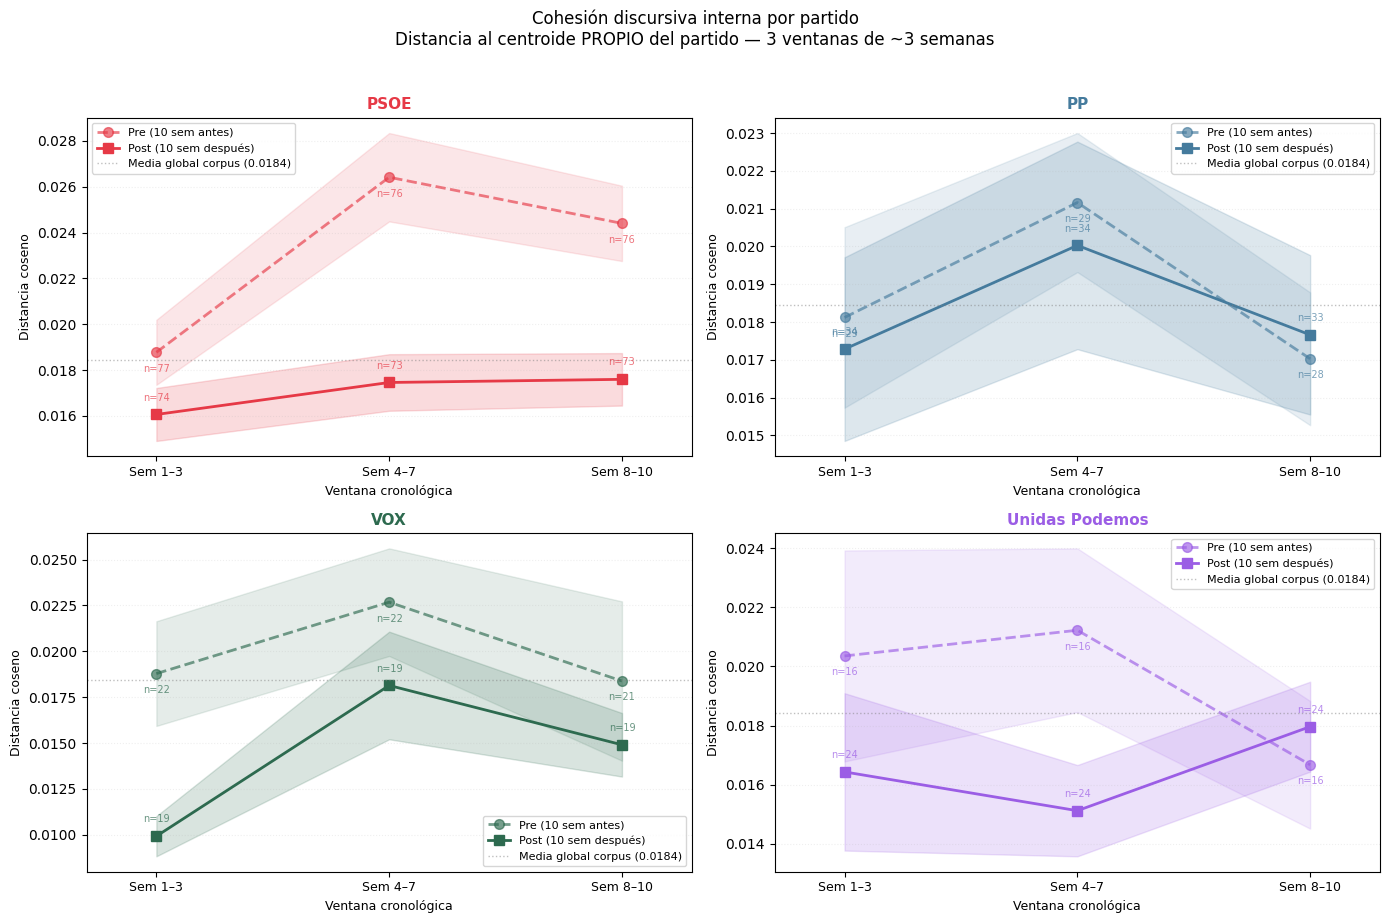

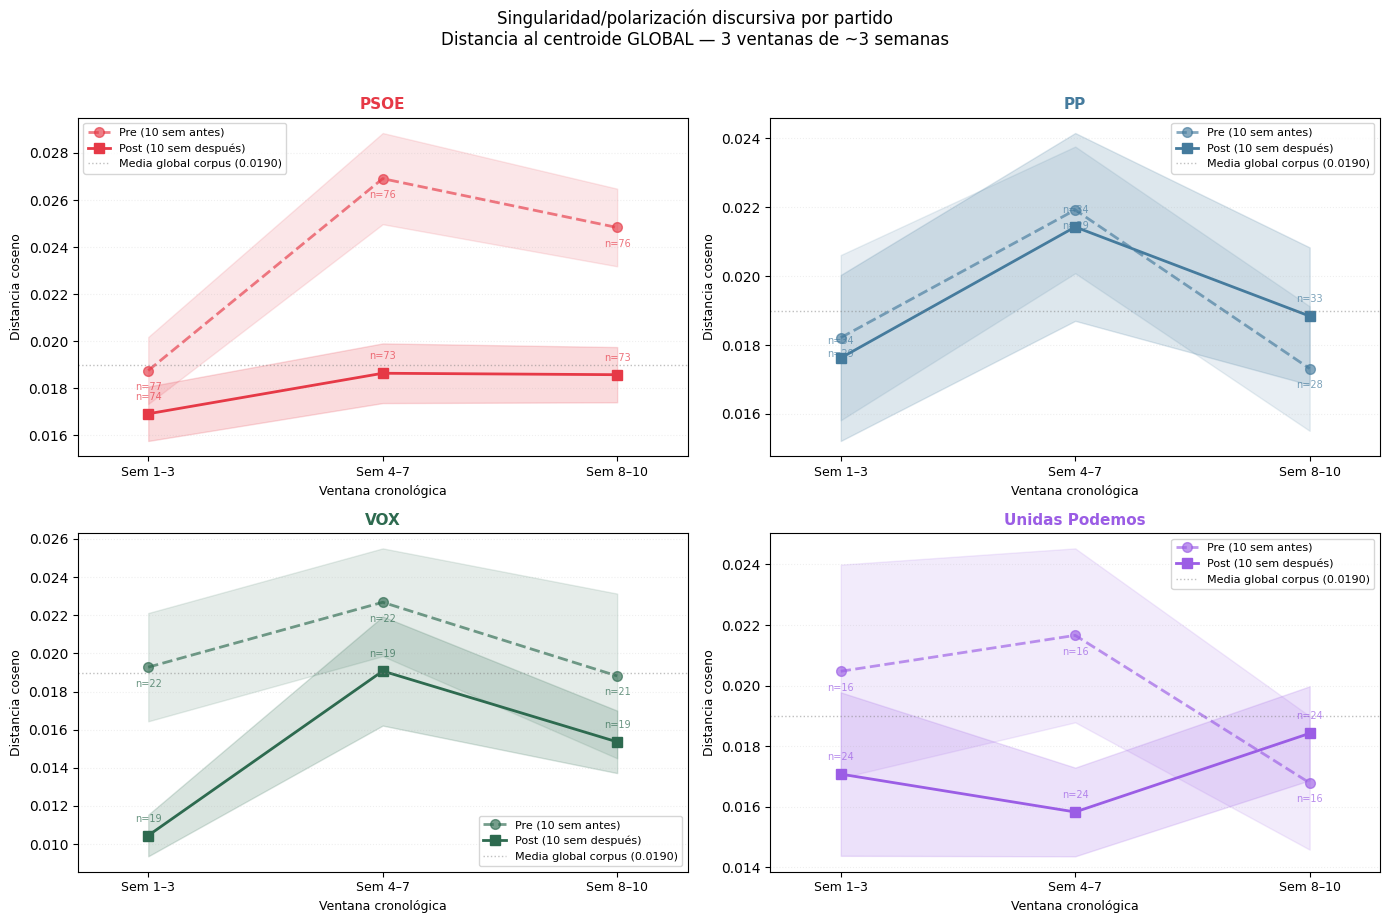

In [ ]:
# ============================================================
# VISUALIZACIÓN TEMPORAL: dos figuras con referencia global
# Fig. 1 = distancia al centroide propio
# Fig. 2 = distancia al centroide global
# ============================================================

from IPython.display import display

# Ambas figuras con ejes Y independientes
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9), sharey=False)

# Calcular la referencia global ANTES de llamar a plot_metrica

# Para Fig 1: distancia media de TODOS al centroide PROPIO de su partido
# (media ponderada por n de todas las ventanas y partidos)
ref_propio = df_vent["mean_propio"].mean()

# Para Fig 2: distancia media de TODOS al centroide GLOBAL
ref_global = df_vent["mean_global"].mean()

# Actualizar plot_metrica para recibir la referencia como parámetro
def plot_metrica(ax, partido, metrica_mean, metrica_se, color, ref_linea, label_ref):
    for periodo, estilo in estilos_periodo.items():
        sub = (df_vent[(df_vent["partido"] == partido) & (df_vent["periodo"] == periodo)]
               .sort_values("ventana"))
        if sub.empty:
            continue

        ax.plot(sub["ventana"], sub[metrica_mean],
                linestyle=estilo["ls"], marker=estilo["marker"],
                color=color, alpha=estilo["alpha_line"],
                label=estilo["label"], linewidth=2, markersize=7)
        # Banda de error alrededor de la media
        ax.fill_between(sub["ventana"],
                        sub[metrica_mean] - sub[metrica_se],
                        sub[metrica_mean] + sub[metrica_se],
                        color=color, alpha=estilo["alpha_band"])

        for _, row in sub.iterrows():
            offset = 10 if periodo == "post" else -14
            ax.annotate(f"n={int(row['n'])}",
                        xy=(row["ventana"], row[metrica_mean]),
                        xytext=(0, offset), textcoords="offset points",
                        ha="center", fontsize=7, color=color, alpha=0.7)

    # Línea de referencia GLOBAL (igual para todos los partidos)
    ax.axhline(ref_linea, color="gray", linewidth=1.0, linestyle=":",
               alpha=0.5, label=f"{label_ref} ({ref_linea:.4f})")

    ax.set_title(partido, fontsize=11, fontweight="bold", color=color)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabels, fontsize=9)
    ax.set_ylabel("Distancia coseno", fontsize=9)
    ax.set_xlabel("Ventana cronológica", fontsize=9)
    ax.tick_params(labelleft=True)   # fuerza números en TODOS los subplots
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.2, linestyle=":")
    ax.set_xlim(0.7, 3.3)


# Fig 1 : Cohesión interna
plt.close("all")
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 9), sharey=False)

for ax, partido in zip(axes1.flatten(), PARTIDOS_PRINCIPALES):
    plot_metrica(ax, partido, "mean_propio", "se_propio",
                 colores[partido], ref_propio, "Media global corpus")

fig1.suptitle(
    "Cohesión discursiva interna por partido\n"
    "Distancia al centroide PROPIO del partido — 3 ventanas de ~3 semanas",
    fontsize=12, y=1.02
)
fig1.tight_layout()
fig1.savefig("fig1_cohesion_interna.png", dpi=150, bbox_inches="tight")
display(fig1)
plt.close(fig1)

# Fig 2: Polarización global
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9), sharey=False)

for ax, partido in zip(axes2.flatten(), PARTIDOS_PRINCIPALES):
    plot_metrica(ax, partido, "mean_global", "se_global",
                 colores[partido], ref_global, "Media global corpus")

fig2.suptitle(
    "Singularidad/polarización discursiva por partido\n"
    "Distancia al centroide GLOBAL — 3 ventanas de ~3 semanas",
    fontsize=12, y=1.02
)
fig2.tight_layout()
fig2.savefig("fig2_polarizacion_global.png", dpi=150, bbox_inches="tight")
display(fig2)
plt.close(fig2)